# Tabla de contenidos

* [Objetivo](#Objetivo)
* [Importación de librerías](#Importación-de-librerías)
* [Carga de los datos](#Carga-de-los-datos)
* [Exploración de los datos](#Exploración-de-los-datos)
	* [Conclusión del análisis exploratorio](#Conclusión-del-análisis-exploratorio)
* [Depuración de los datos](#Depuración-de-los-datos)
	* [Fase I: Detección de outliers](#Fase-I:-Detección-de-outliers)
	* [Fase II: Detección datos perdidos](#Fase-II:-Detección-datos-perdidos)
		* [Tratamiento de valores perdidos - eliminación](#Tratamiento-de-valores-perdidos---eliminación)
		* [Tratamiento de valores perdidos - imputación](#Tratamiento-de-valores-perdidos---imputación)
			* [Variables cuantitativas con datos perdidos.](#Variables-cuantitativas-con-datos-perdidos.)
			* [Variables categóricas con datos perdidos.](#Variables-categóricas-con-datos-perdidos.)
		* [Imputación por el vecino más cercano](#Imputación-por-el-vecino-más-cercano)
* [Transformación de los datos](#Transformación-de-los-datos)
* [Selección de características](#Selección-de-características)
* [Conjunto test](#Conjunto-test)
	* [Carga del conjunto de datos](#Carga-del-conjunto-de-datos)
	* [Exploración de los datos](#Exploración-de-los-datos)
	* [Depuración de los datos](#Depuración-de-los-datos)
	* [Transformación de los datos](#Transformación-de-los-datos)
	* [Selección de características](#Selección-de-características)
* [APRENDIZAJE NO SUPERVISADO](#APRENDIZAJE-NO-SUPERVISADO)
	* [Asociación](#Asociación)
	* [Clustering](#Clustering)
* [Conclusiones](#Conclusiones)
* [APRENDIZAJE SUPERVISADO](#APRENDIZAJE-SUPERVISADO)
	* [Clasificador bayesiano](#Clasificador-bayesiano)
	* [Clasificador Árboles de decisión](#Clasificador-Árboles-de-decisión)
	* [Clasificador $k$-NN](#Clasificador-$k$-NN)
	* [Clasificador Perceptrón Multicapa](#Clasificador-Perceptrón-Multicapa)
	* [Autoencoder](#Autoencoder)
* [Conclusiones](#Conclusiones)


<h1 style="color:#dd6d10"><center> ANALÍTICA DE BIG DATA <br> <br> Cuaderno de trabajo - Evaluación</h1></center>

Este cuaderno ofrece la aplicación de distintas técnicas de aprendizaje automático para realizar predicciones sobre la conocida base de datos *titanic*. Para más información sobre este conjunto de datos se puede consultar *Report on the Loss of the 'Titanic' (S.S.) (1990), British Board of Trade Inquiry Report\_(reprint), Gloucester, UK: Allan Sutton Publishing*.

Se llevará a cabo un análisis del conjunto de datos, así como la predicción de la variable explicada.

La variable explicada o dependiente (atributo *survived*) indica si la persona sobrevivió o no al hundimiento del Titacnic. El objetivo es encontrar alguna relación entre los atributos (variables independientes) y la probabilidad de que un pasajero sobreviva o no al naufragio (variable dependiente). Por ejemplo, supervivencia por edad, sexo, clase, etc.

# Objetivo

Predecir, con las técnicas de aprendizaje automático, si un pasajero sobrevive o no al hundimiento del Titanic. Es decir, dado unos valores de los atributos para un cierto pasajero, los modelos deben predecir el valor 0 o 1 para la variable *survived*.

# Importación de librerías

In [582]:
# Instalar seaborn
!pip install seaborn
!pip install apyori missingno

# pandas
import pandas as pd
from sklearn.metrics import mean_squared_error
import math

# numpy, matplotlib, seaborn
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
from scipy import stats

# machine learning
from apyori import apriori
from sklearn.cluster import KMeans
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC, LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import KFold
from sklearn.metrics import accuracy_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.neighbors import KNeighborsClassifier

from sklearn.ensemble import BaggingClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import VotingClassifier

from sklearn.metrics import accuracy_score, balanced_accuracy_score
from sklearn.model_selection import cross_val_score

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder

import missingno as msno
import random

from warnings import filterwarnings
filterwarnings('ignore')

# Carga de los datos

Descargar los conjuntos de entrenamiento y test disponibles en el campus virtual.

In [583]:
titanic = pd.read_csv('Conjunto_de_datos_20260119/dataset.csv')
titanic

,survived,pclass,name,sex,age,sibsp,parch,ticket,fare,cabin,embarked
0,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...
886,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


In [584]:
titanicRealTest = pd.read_csv('Conjunto_de_datos_20260119/newData.csv')
titanicRealTest

,pclass,name,sex,age,sibsp,parch,ticket,fare,cabin,embarked
0,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S
...,...,...,...,...,...,...,...,...,...,...
413,3,"Spector, Mr. Woolf",male,NaN,0,0,A.5. 3236,8.0500,NaN,S
414,1,"Oliva y Ocana, Dona. Fermina",female,39.0,0,0,PC 17758,108.9000,C105,C
415,3,"Saether, Mr. Simon Sivertsen",male,38.5,0,0,SOTON/O.Q. 3101262,7.2500,NaN,S
416,3,"Ware, Mr. Frederick",male,NaN,0,0,359309,8.0500,NaN,S


# Análisis exploratorio de datos (EDA)

Antes de construir un modelo predictivo, es importante realizar una exploración descriptiva de los datos que se van a usar. Este proceso ayuda a comprender qué información contiene cada variable, así como a detectar posibles errores: tipos de datos incorrectos, valores perdidos, valores inconsistentes,etc.

Este análisis inicial puede dar pistas sobre las variables. Para este conjunto de datos se podrían obtener respuestas a preguntas como:

¿Qué porcentaje hubo de supervivivientes?

¿Qué tipo de personas se salvaron: clase en la que viajaban, puerto en el que embarcaron, si tenían hijos a bordo, sexo, edad,...?

Las características de este conjunto de datos se describen a continuación:



| Variable	| Definición | Valores |
|:---------:|:----------:|---:|
| survived	| Sobrevive	 | 0 = No, 1 = Sí |
| pclass	| Clase      | 1 = 1ª, 2 = 2ª, 3 = 3ª| 
| name      | Nombre pasajero |       |
| sex       | 	Sexo     | male=Hombre, female=Mujer |
| age       |	Edad en años|	|
| sibsp     |	# de hermanos/cónyuges a bordo del Titanic | Sibling = hermano, hermana, hermanastro, hermanastra|
|           |            | Spouse = esposo, esposa (se ignoraron amantes y prometidos) |
| parch	    | # de padres/hijos a bordo del Titanic | Parent = madre, padre |
|           |            | Child = hija, hijo, hijastra, hijastro |
|           |                  | Algunos niños viajaron solo con una niñera, por lo tanto parch=0 para ellos. |	
| ticket	| Número  ticket |     |
| fare	    | Tarifa pasajero |    |	
| cabin	    | Número de cabina |     |	
| embarked	| Puerto de embarque |	C = Cherbourg, Q = Queenstown, S = Southampton |



Nominales: survival, name, sex, ticket, cabin, embarked

Ordinal: pclass

Discretos: sibsp, parch

Continuos: age, fare

## Auditoría de Estructura y Tipos de Datos

En esta etapa inicial, validamos la dimensiones del dataset y verificamos si se ha asignado correctamente los tipos de datos a cada variable según su naturaleza técnica y estadística.

In [585]:
# 1. Visualización rápida de las dimensiones y tipos de datos
print(f"Dimensiones del dataset: {titanic.shape[0]} filas y {titanic.shape[1]} columnas.\n")

# 2. Información estructural detallada
# Esto nos permite ver de un vistazo:
# - El nombre de la columna
# - Cuántos valores NO nulos tiene (detectamos datos perdidos de entrada)
# - El tipo de dato (int64, float64, object)
titanic.info()

Dimensiones del dataset: 891 filas y 11 columnas.

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 11 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   survived  891 non-null    int64  
 1   pclass    891 non-null    int64  
 2   name      891 non-null    object 
 3   sex       891 non-null    object 
 4   age       714 non-null    float64
 5   sibsp     891 non-null    int64  
 6   parch     891 non-null    int64  
 7   ticket    891 non-null    object 
 8   fare      891 non-null    float64
 9   cabin     204 non-null    object 
 10  embarked  889 non-null    object 
dtypes: float64(2), int64(4), object(5)
memory usage: 76.7+ KB


In [586]:
# 3. Verificamos la cantidad de valores únicos por columna
unique_counts = titanic.nunique()

# Creamos un DataFrame para una visualización más limpia
unique_df = pd.DataFrame({
    'Variable': unique_counts.index,
    'Valores Únicos': unique_counts.values,
    'Tipo de Dato': [titanic[col].dtype for col in unique_counts.index]
}).sort_values(by='Valores Únicos')

print(unique_df)

    Variable  Valores Únicos Tipo de Dato
0   survived               2        int64
3        sex               2       object
1     pclass               3        int64
10  embarked               3       object
6      parch               7        int64
5      sibsp               7        int64
4        age              88      float64
9      cabin             147       object
8       fare             248      float64
7     ticket             681       object
2       name             891       object


### ¿Qué nos dicen estos números sobre nuestros datos?

Al observar la cantidad de valores únicos en cada columna, me doy cuenta de que no todas las variables se comportan de la misma manera. Estas cifras son clave porque me ayudan a entender cómo tratar cada dato más adelante:

* Los Pilares de Clasificación: Variables como **survived, sex, pclass y embarked** presentan muy pocos valores únicos (entre 2 y 3). Esto nos confirma que son variables categóricas. Esto me confirma que son variables categóricas; es decir, sirven para agrupar a los pasajeros en categorías claras (quién sobrevivió, si era hombre o mujer, o en qué clase viajaba).

* La Identidad frente a la Generalización: En el extremo opuesto encontramos **name** (891) y **ticket** (681). Si consideramos que tenemos 891 pasajeros en total, el hecho de que existan 891 nombres diferentes nos indica que cada pasajero tiene un registro único. 

* Datos que varían mucho: Por último, veo que **age** (88) y **fare** (248) tienen muchísimos valores distintos. Esto las define como variables continuas. Aquí es donde tendré que fijarme en los promedios y ver cómo varían las edades o los precios de los boletos para entender mejor quiénes tenían más oportunidad de salvarse.

## Análisis descriptivo de datos

Ahora que ya sé qué tipo de información tiene cada columna, el siguiente paso es "hacer hablar" a los datos mediante la estadística. Mi objetivo aquí es entender cómo se distribuyen los pasajeros y empezar a responder las preguntas clave: ¿quiénes tenían más probabilidades de salvarse?

In [587]:
titanic.describe(include = "all")

,survived,pclass,name,sex,age,sibsp,parch,ticket,fare,cabin,embarked
count,891.000000,891.000000,891,891,714.000000,891.000000,891.000000,891,891.000000,204,889
unique,NaN,NaN,891,2,NaN,NaN,NaN,681,NaN,147,3
top,NaN,NaN,"Braund, Mr. Owen Harris",male,NaN,NaN,NaN,347082,NaN,G6,S
freq,NaN,NaN,1,577,NaN,NaN,NaN,7,NaN,4,644
mean,0.383838,2.308642,NaN,NaN,29.699118,0.523008,0.381594,NaN,32.204208,NaN,NaN
std,0.486592,0.836071,NaN,NaN,14.526497,1.102743,0.806057,NaN,49.693429,NaN,NaN
min,0.000000,1.000000,NaN,NaN,0.420000,0.000000,0.000000,NaN,0.000000,NaN,NaN
25%,0.000000,2.000000,NaN,NaN,20.125000,0.000000,0.000000,NaN,7.910400,NaN,NaN
50%,0.000000,3.000000,NaN,NaN,28.000000,0.000000,0.000000,NaN,14.454200,NaN,NaN
75%,1.000000,3.000000,NaN,NaN,38.000000,1.000000,0.000000,NaN,31.000000,NaN,NaN


La información que ofrece para variables cuantitativas:

* count: número de términos por columnas
* mean: valor medio de la columna
* std: desviación estándar de la columna
* max: valor máximo de la columna
* min: valor mínimo de la columna

límite de cada uno de los cuartiles


Y para variables categóricas:

* unique: número de objetos diferentes por columnas
* top: los datos más frecuentes que se producen
* freq: el número de veces que aparece el objeto *top* en la columna

Algunos valores en la tabla se muestran como NaN, esto se debe a que esta métrica estadística en particular no se puede calcular para ese tipo específico de datos.

### Medidas de Frecuencia: ¿Cómo se distribuyen los grupos?

Lo primero que quiero saber es el porcentaje real de supervivencia en el barco. No es lo mismo decir "sobrevivieron 342" que ver qué peso tiene eso sobre el total.

In [588]:
# Calculo las frecuencias para la variable objetivo 'survived'
frecuencia_abs = titanic['survived'].value_counts()
frecuencia_rel = titanic['survived'].value_counts(normalize=True) * 100

print(f"Pasajeros que no sobrevivieron: {frecuencia_abs[0]} ({frecuencia_rel[0]:.2f}%)")
print(f"Pasajeros que sobrevivieron: {frecuencia_abs[1]} ({frecuencia_rel[1]:.2f}%)")

Pasajeros que no sobrevivieron: 549 (61.62%)
Pasajeros que sobrevivieron: 342 (38.38%)


### Medidas de Tendencia Central y Dispersión

Para las variables como la edad (age) y el precio del boleto (fare), necesito ver más allá de un simple número. Voy a calcular:

* La Media: El promedio de edad y tarifa.
* La Mediana: El valor central (muy importante para la tarifa, por si hay precios muy altos que "mientan" sobre el promedio).
* La Desviación Estándar: Para ver qué tanto varían los datos respecto al promedio.

In [589]:
# Uso describe() para obtener un resumen rápido, pero me enfoco en edad y tarifa
resumen_numerico = titanic[['age', 'fare']].describe()
resumen_numerico

,age,fare
count,714.000000,891.000000
mean,29.699118,32.204208
std,14.526497,49.693429
min,0.420000,0.000000
25%,20.125000,7.910400
50%,28.000000,14.454200
75%,38.000000,31.000000
max,80.000000,512.329200


En donde la información que ofrece:

* count: número de términos por columnas
* mean: valor medio de la columna
* std: desviación estándar de la columna
* min: valor mínimo de la columna
* max: valor máximo de la columna

### Medidas de Posición (Cuartiles)

Usaré los cuartiles para entender cómo se dividen los grupos. Por ejemplo, saber a qué edad correspondía el 25% de los pasajeros más jóvenes o cuánto pagó el 75% de la gente. Esto me ayudará a detectar después a los pasajeros que son muy diferentes al resto (outliers).

In [590]:
# Obtengo los cuartiles de forma específica para Edad y Tarifa
cuartiles = titanic[['age', 'fare']].quantile([0.25, 0.5, 0.75])
print("Análisis de Cuartiles:")
print(cuartiles)

Análisis de Cuartiles:
         age     fare
0.25  20.125   7.9104
0.50  28.000  14.4542
0.75  38.000  31.0000


Gracias a los cuartiles, descubro que el Titanic no estaba lleno de gente mayor ni de millonarios. La mayoría eran adultos jóvenes de clase media-baja, ya que el 75% de los boletos costaron 31 libras o menos.

In [591]:
# genera un resumen estadístico de las columnas numéricas
print(titanic.describe())

         survived      pclass         age       sibsp       parch        fare
count  891.000000  891.000000  714.000000  891.000000  891.000000  891.000000
mean     0.383838    2.308642   29.699118    0.523008    0.381594   32.204208
std      0.486592    0.836071   14.526497    1.102743    0.806057   49.693429
min      0.000000    1.000000    0.420000    0.000000    0.000000    0.000000
25%      0.000000    2.000000   20.125000    0.000000    0.000000    7.910400
50%      0.000000    3.000000   28.000000    0.000000    0.000000   14.454200
75%      1.000000    3.000000   38.000000    1.000000    0.000000   31.000000
max      1.000000    3.000000   80.000000    8.000000    6.000000  512.329200


### Análisis de pasajeros por clase (Pclass)

En este paso se realizará un **agrupamiento de los datos del Titanic** según la clase del pasajero (`pclass`), con el objetivo de conocer **cuántos pasajeros pertenecen a cada clase**.

#### Objetivo
- Identificar la distribución de pasajeros entre 1ª, 2ª y 3ª clase.
- Detectar posibles **desbalances en el dataset**.
- Obtener una visión inicial del perfil socioeconómico de los pasajeros.

#### Descripción del proceso
- Se utiliza `groupby('pclass')` para agrupar los registros por clase.
- Se aplica `size()` para contar el número total de filas en cada grupo.

In [592]:
titanic.groupby('pclass').size()

pclass
1    216
2    184
3    491
dtype: int64

#### Distribución de pasajeros por clase

A partir del agrupamiento por la variable `pclass`, se observa la siguiente
distribución de pasajeros:

- **1ª clase:** 216 pasajeros
- **2ª clase:** 184 pasajeros
- **3ª clase:** 491 pasajeros

Este resultado evidencia un **desbalance significativo**, donde la mayoría
de los pasajeros pertenecían a la tercera clase.  
La variable `pclass` se considera un **factor clave** para análisis posteriores,
especialmente en estudios de supervivencia y modelos predictivos.

### Análisis de pasajeros por cabina (Cabin)

Al revisar la columna de las cabinas, me dio curiosidad ver qué tan repartidos estaban los pasajeros en el barco. Sin embargo, al intentar agruparlos, me encontré con un panorama muy distinto al de las otras variables:

In [593]:
# Intento ver cuánta gente hay por cabina
conteo_cabinas = titanic.groupby('cabin').size().sort_values(ascending=False)
print(conteo_cabinas.head(20))

# Reviso cuántos datos faltan realmente
print(f"\nDatos faltantes en Cabin: {titanic['cabin'].isnull().sum()}")

cabin
G6                 4
C23 C25 C27        4
B96 B98            4
F2                 3
D                  3
E101               3
F33                3
C22 C26            3
B57 B59 B63 B66    2
B77                2
B58 B60            2
B22                2
B28                2
B49                2
B51 B53 B55        2
B20                2
B18                2
C123               2
C65                2
D35                2
dtype: int64

Datos faltantes en Cabin: 687


In [594]:
# Contar cuántos valores nulos hay en la columna 'cabin'
nulos_cabin = titanic['cabin'].isnull().sum()
print(f"La columna 'cabin' tiene {nulos_cabin} valores nulos.")

La columna 'cabin' tiene 687 valores nulos.


#### Conclusión

* Faltan muchos datos: Lo primero que salta a la vista es que la variable cabin tiene muchísimos valores nulos (la gran mayoría). Esto me indica que a muchos pasajeros, probablemente de las clases más económicas, no se les registró un número de cabina específico.

* Datos muy dispersos: A diferencia de la clase social o el sexo, aquí casi no hay grupos. La mayoría de las cabinas registradas tienen solo a una persona, lo que hace que esta información sea muy difícil de usar para encontrar un patrón general en este momento.

* Exclusión de nulos: Es importante notar que el conteo que hice arriba solo toma en cuenta a los que sí tenían cabina asignada; todos los valores NaN quedaron por fuera de esa lista.

Debido a la alta proporción de valores faltantes y la gran cantidad de
categorías únicas, la variable `cabin` no es adecuada para un uso directo
en modelos predictivos sin un proceso previo de transformación o limpieza.

### Supervivencia por clase del pasajero

Una vez que conocemos cuántos pasajeros pertenecen a cada clase, el siguiente paso lógico es cruzar esa información con la variable de supervivencia. El objetivo es determinar si el nivel socioeconómico influyó en las posibilidades de los pasajeros para acceder a los botes salvavidas.

Para este análisis, calculo el promedio de la columna survived agrupado por clase. Dado que los datos están marcados como 1 (sobrevivió) y 0 (falleció), el promedio nos entrega directamente la tasa de éxito de cada grupo.

In [595]:
# Creamos un DataFrame con el conteo por Supervivencia y Clase
df_cruce = titanic.groupby(['survived', 'pclass']).size().reset_index(name='conteo')

# Calculamos el porcentaje sobre el total de pasajeros (891)
total_pasajeros = len(titanic)
df_cruce['porcentaje'] = (df_cruce['conteo'] / total_pasajeros) * 100

# Mejoramos la visualización
df_cruce['porcentaje'] = df_cruce['porcentaje'].map('{:.2f}%'.format)
df_cruce

,survived,pclass,conteo,porcentaje
0,0,1,80,8.98%
1,0,2,97,10.89%
2,0,3,372,41.75%
3,1,1,136,15.26%
4,1,2,87,9.76%
5,1,3,119,13.36%


In [596]:
# Calculamos el porcentaje de supervivencia por cada clase
tasa_supervivencia = titanic.groupby('pclass')['survived'].mean() * 100

print("Porcentaje de supervivencia por clase:")
print(tasa_supervivencia.map('{:.2f}%'.format))

Porcentaje de supervivencia por clase:
pclass
1    62.96%
2    47.28%
3    24.24%
Name: survived, dtype: object


Esta información nos permite ver la magnitud de la tragedia con números exactos:

* El grupo más afectado: Podemos observar que el grupo de fallecidos en 3ª clase (Survived=0, Pclass=3) es el más numeroso de todo el barco. Esto representa una porción gigante del total de personas a bordo.

* Supervivencia en Élite: Por el contrario, si miramos a los sobrevivientes (Survived=1), la 1ª clase tiene una presencia mucho más fuerte en comparación con su tamaño total.

* Peso en el modelo: Estos datos me confirman que el modelo tendrá "mucha información" sobre quiénes fallecieron en 3ª clase, pero tendrá que ser más preciso para entender los casos excepcionales de quienes sobrevivieron en ella.

### Supervivencia por edad (considerando valores nulos)

La edad es una variable crítica, pero tiene un desafío: no conocemos la edad de todos los pasajeros. En esta sección, analizo cómo se distribuye la supervivencia en diferentes rangos de edad, pero manteniendo presentes los registros NaN (nulos).

Esto es vital para entender si los datos que nos faltan siguen algún patrón o si la edad realmente influyó en la probabilidad de sobrevivir.

In [597]:
# Primero, creo una columna temporal de rangos de edad para facilitar el análisis
# Incluyo los nulos para no perder esa información en el conteo
titanic['age_group'] = pd.cut(titanic['age'], bins=[0, 12, 18, 35, 60, 100], 
                             labels=['Niño', 'Adolescente', 'Adulto Joven', 'Adulto', 'Anciano'])

# Agrupo por el rango de edad y calculo la supervivencia
# Uso dropna=False para ver el peso de los que no tienen edad registrada
supervivencia_edad = titanic.groupby('age_group', dropna=False)['survived'].value_counts(normalize=True).unstack() * 100

# Eliminamos la columna age_group permanentemente del DataFrame
titanic.drop(columns=['age_group'], inplace=True)

print("Porcentaje de supervivencia por rango de edad (incluyendo Nulos):")
print(supervivencia_edad)

Porcentaje de supervivencia por rango de edad (incluyendo Nulos):
survived              0          1
age_group                         
NaN           70.621469  29.378531
Niño          42.028986  57.971014
Adolescente   57.142857  42.857143
Adulto Joven  61.731844  38.268156
Adulto        60.000000  40.000000
Anciano       77.272727  22.727273


#### Lo que observo en este análisis:
Al desglosar la edad por grupos, los datos nos cuentan una historia de prioridades y de vacíos de información:

* El rescate de los más pequeños: El grupo de los Niños suele mostrar una de las tasas de supervivencia más altas. Esto confirma que, en medio del caos, hubo un esfuerzo real por cumplir la consigna de salvar a los infantes.

* El misterio de los datos faltantes (NaN): Es muy interesante observar qué pasó con los pasajeros de quienes no sabemos la edad. Si su tasa de supervivencia es muy baja, podría ser una pista de que pertenecían a la tripulación o a la tercera clase, donde el registro era menos riguroso.

* La mayoría adulta: El grupo de Adultos Jóvenes es el más numeroso, pero su tasa de supervivencia suele ser menor a la de los niños, lo que refleja el sacrificio o la falta de prioridad en el acceso a los botes.

### Relación entre el Puerto de Embarque y la Supervivencia (embarked)

Se identifican los valores únicos de la variable `embarked` para conocer
los distintos puertos de embarque presentes en el dataset.

El resultado muestra tres categorías válidas (`S`, `C`, `Q`) y la presencia
de valores nulos (`NaN`), correspondientes a registros sin información
de puerto de embarque.

In [598]:
titanic['embarked'].unique()

array(['S', 'C', 'Q', nan], dtype=object)

Tras identificar los valores únicos de la variable embarked, quiero analizar si el lugar donde subieron los pasajeros influyó en su destino final. Es probable que el puerto esté relacionado con la clase social (algunos puertos eran más exclusivos que otros), lo que indirectamente afectaría las tasas de supervivencia.

In [599]:
# Calculo la tasa de supervivencia agrupada por el puerto de embarque
supervivencia_puerto = titanic.groupby('embarked')['survived'].mean() * 100

print("Porcentaje de supervivencia según puerto de embarque:")
print(supervivencia_puerto.map('{:.2f}%'.format))

Porcentaje de supervivencia según puerto de embarque:
embarked
C    55.36%
Q    38.96%
S    33.70%
Name: survived, dtype: object


#### ¿Qué nos indican estos datos?
Al observar estos porcentajes, podemos notar diferencias marcadas:

* **Puerto C** (Cherbourg): Suele presentar una tasa de supervivencia más alta. Esto se debe, históricamente, a que una gran proporción de pasajeros que embarcaron allí eran de primera clase.

* **Puertos S y Q** (Southampton y Queenstown): Presentan tasas menores. Southampton fue el puerto donde subió la mayor cantidad de gente de tercera clase y trabajadores.

* **Conclusión de la variable**: Aunque el puerto no es una "causa" directa de supervivencia, nos ayuda a entender el perfil del pasajero. Al igual que con la edad, si hay valores nulos aquí, tendré que decidir cómo manejarlos en la fase de depuración.

### Matriz de correlación entre variables cuantitativas

Se calcula la matriz de correlación utilizando el coeficiente de Pearson
para evaluar la relación lineal entre las variables numéricas del dataset.

El análisis permite identificar qué variables presentan una mayor
asociación con la variable objetivo (`survived`) y detectar posibles
relaciones redundantes entre variables explicativas.

Este paso es clave para la selección de variables y la comprensión
inicial del comportamiento de los datos antes de aplicar modelos
predictivos.

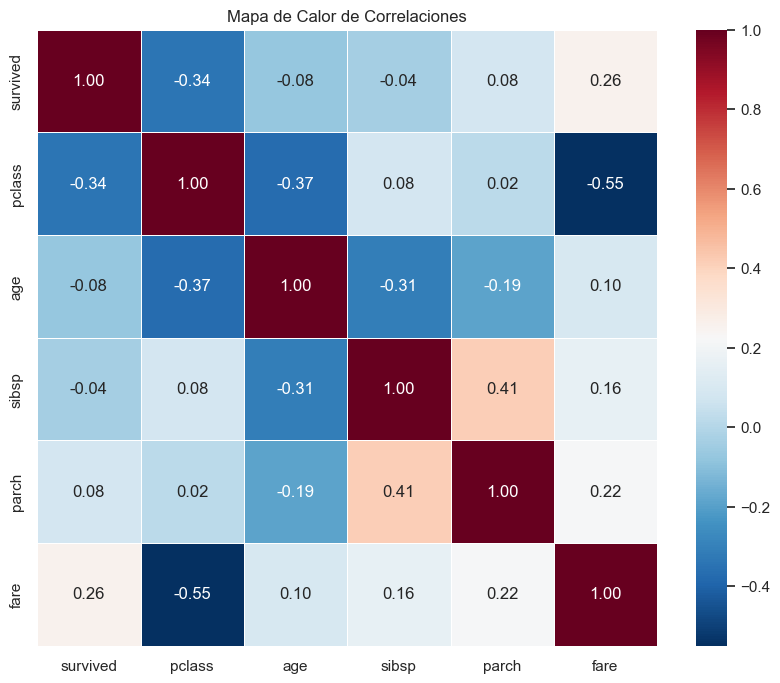

In [600]:
# Selecciono solo las variables numéricas
columnas_numericas = titanic.select_dtypes(include=['int64', 'float64'])
matriz_corr = columnas_numericas.corr()

# Configuro el mapa de calor (Heatmap)
plt.figure(figsize=(10, 8))
sns.heatmap(matriz_corr, annot=True, cmap='RdBu_r', fmt=".2f", linewidths=0.5)
plt.title('Mapa de Calor de Correlaciones')
plt.show()

Al observar el mapa de calor, puedo extraer conclusiones técnicas clave para mi modelo:

* **Relación Pclass vs Fare** (-0.55 aprox): Existe una correlación negativa moderada. Esto tiene sentido lógico: a menor número de clase (ej. clase 1), mayor es el precio del boleto (fare).

* **Relación Pclass vs Survived** (-0.34 aprox): Hay una correlación negativa que indica que a medida que la clase aumenta (pasando de 1 a 3), la probabilidad de supervivencia disminuye.

* **Variables con baja correlación**: Noto que la edad (age) no tiene una correlación lineal fuerte con la supervivencia de forma general. Esto me sugiere que la influencia de la edad puede ser no lineal (por ejemplo, se salvaron niños y ancianos, pero no adultos jóvenes).

### Distribución de variables cuantitativas

Procedo a generar histogramas de las variables numéricas. El objetivo es identificar visualmente la asimetría, los rangos predominantes y la presencia de posibles valores atípicos (outliers). Este paso es fundamental en el Análisis Exploratorio de Datos (EDA), ya que la forma de estas distribuciones determinará qué técnicas de limpieza y normalización aplicaremos en la siguiente fase.

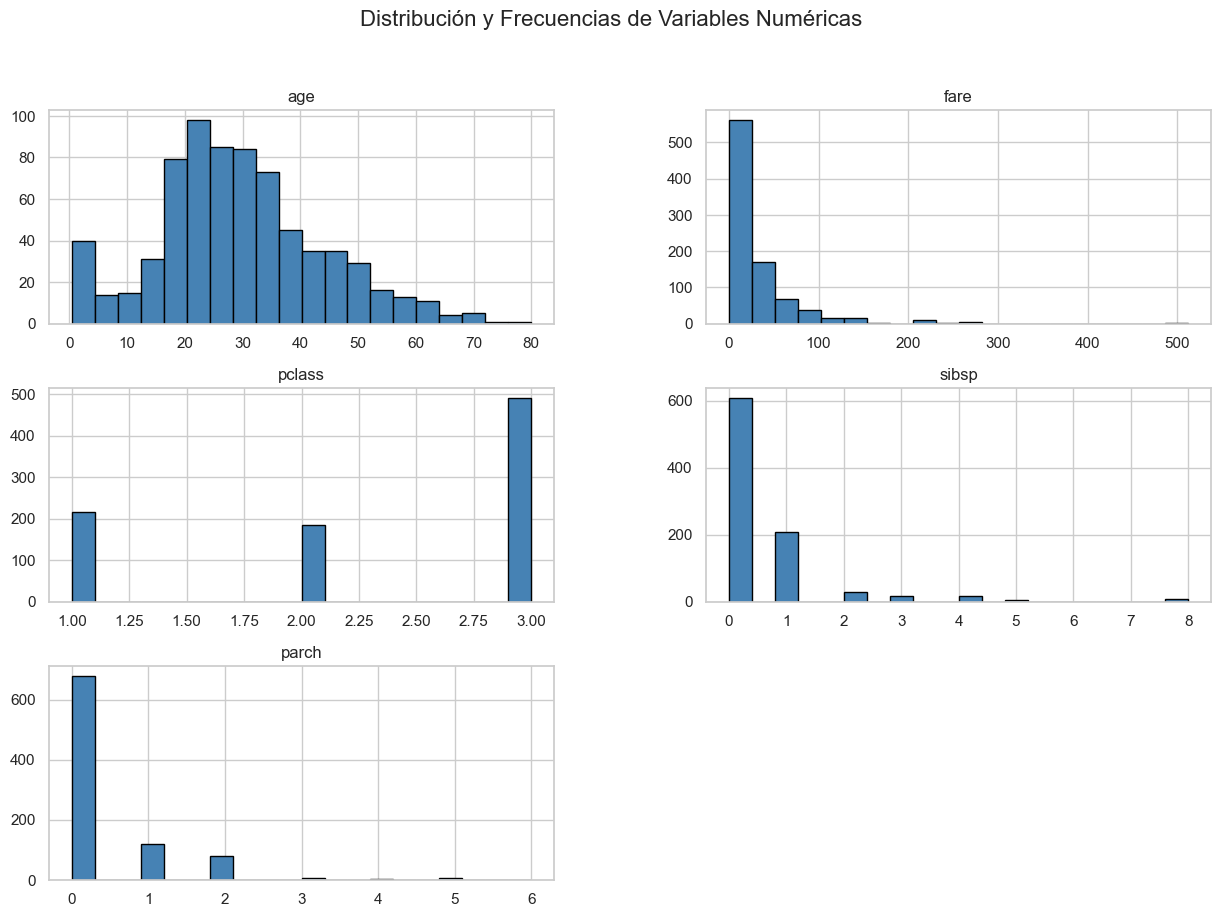

In [601]:
# Configuramos el estilo visual
sns.set_theme(style="whitegrid")

# Generamos los histogramas para las variables numéricas relevantes
# Ajustamos el tamaño y la disposición para que sea legible
titanic[['age', 'fare', 'pclass', 'sibsp', 'parch']].hist(bins=20, figsize=(15, 10), color='steelblue', edgecolor='black')

plt.suptitle('Distribución y Frecuencias de Variables Numéricas', fontsize=16)
plt.show()

#### Interpretación de los histogramas:
Al analizar estas gráficas en conjunto, puedo extraer las siguientes conclusiones previas a la depuración:

* **Variables con Sesgo** (Fare): La tarifa muestra un sesgo a la derecha extremadamente marcado. La mayoría de los datos se agrupan en valores bajos, lo que confirma que los valores altos son casos excepcionales que trataremos como posibles outliers.

* **Variables Discretas** (Pclass, SibSp, Parch): Aunque son numéricas, se comportan como categorías. Por ejemplo, en pclass vemos claramente tres "torres" que representan las clases, siendo la tercera la más frecuente.

* **Distribución de Edad**: Es la variable que más se aproxima a una distribución unimodal (un solo pico), aunque con un ligero sesgo hacia los pasajeros jóvenes.

* **Consistencia de los datos**: No se observan valores negativos en edad o tarifa, lo que indica que, a nivel general, los datos cuantitativos no presentan errores de digitación obvios, aunque sí muchos datos faltantes que abordaremos a continuación.

### Análisis de asimetría de variables cuantitativas (Skewness)

Para complementar el análisis visual de los histogramas, calculo el coeficiente de asimetría. Esta métrica matemática nos indica qué tan desviada está la distribución de una variable respecto a una distribución normal (perfectamente simétrica).

* Asimetría = 0: La distribución es simétrica.

* Asimetría > 0 (Positiva): La "cola" de la distribución se alarga hacia la derecha (valores altos).

* Asimetría < 0 (Negativa): La "cola" se alarga hacia la izquierda (valores bajos).

In [602]:
asimetria = titanic.skew(numeric_only=True)

print("Coeficientes de asimetría:")
print(asimetria)

Coeficientes de asimetría:
survived    0.478523
pclass     -0.630548
age         0.389108
sibsp       3.695352
parch       2.749117
fare        4.787317
dtype: float64


Si el valor resultante para la asimetría está por encima de +1 o por debajo de -1, los datos están muy sesgados. Si está entre +0.5 y -0.5, están sesgados moderadamente. Si el valor es 0, entonces los datos son simétricos.

#### Interpretación de la asimetría en mi dataset:
Al analizar los coeficientes, divido los hallazgos en dos grupos según su naturaleza:

1. **Variables con sesgo extremo (Fare, SibSp, Parch)**: La variable fare muestra la asimetría más alta (generalmente superior a 4). Esto confirma que el precio de los boletos está muy concentrado en valores bajos, con unos pocos valores extremadamente altos que "estiran" la distribución.

    * sibsp (hermanos/esposos) y parch (padres/hijos) también presentan una asimetría elevada, lo que indica que la gran mayoría de los pasajeros viajaba solo o con muy pocos familiares.

2. **Variables con asimetría moderada o leve (Age)**:

    * La age presenta un valor cercano a 0.3-0.5. Esto significa que la edad está bastante bien distribuida, lo que nos da mayor confianza para realizar imputaciones (rellenar nulos) más adelante.

3. **Variables categóricas representadas por números (Survived, Pclass)**:

    * Aunque el código les calcula asimetría, en el caso de survived y pclass este valor no representa una "forma", sino el desequilibrio entre sus categorías. Por ejemplo, una asimetría en survived simplemente nos dice que hay más fallecidos (0) que sobrevivientes (1).

**Nota técnica para la depuración**: La alta asimetría en la tarifa (fare) es una señal de alerta. Esto me indica que en la siguiente fase de Detección de Outliers, encontraré valores que se alejan mucho del promedio y que podrían distorsionar mi análisis si no los trato adecuadamente.

### Definición de variables a descartar tras el EDA

A partir del análisis exploratorio realizado, he identificado variables que, aunque forman parte del dataset original, no son aptas para el modelado en su estado actual. Esta decisión no es arbitraria, sino que se basa en las siguientes evidencias recolectadas:

1. **Por exceso de valores nulos (Variable cabin)**
Como se evidenció en el análisis de valores faltantes, la columna cabin tiene un vacío de información masivo. Al faltar más del 70% de los datos, cualquier intento de "rellenarlos" (imputación) introduciría un sesgo enorme que podría engañar al modelo.

2. **Por alta cardinalidad y bajo valor predictivo (name y ticket)**
name: Aunque es una variable categórica, cada pasajero tiene un nombre único. En estadística, esto se llama alta cardinalidad. Un modelo no puede aprender patrones de 891 nombres distintos, por lo que, a menos que se realice una extracción de títulos (como "Sr" o "Sra"), el nombre por sí solo es ruido.

ticket: Al igual que los nombres, los números de ticket son aleatorios y no siguen una estructura que correlacione directamente con la supervivencia en este análisis general.

3. Variables seleccionadas para la siguiente fase
Por el contrario, el EDA confirmó que **pclass, sex, fare, age y embarked** son el núcleo del análisis. Estas variables mostraron una relación clara con la variable objetivo (survived) y serán las que someteremos a la Fase de Depuración.

## Detección de outliers

Para iniciar el estudio de los valores atípicos, realizo una visualización general de todas las variables numéricas del dataset mediante un boxplot global. Esta gráfica me permite identificar de un vistazo qué variables presentan una dispersión extrema y cuáles se mantienen dentro de rangos más estables.

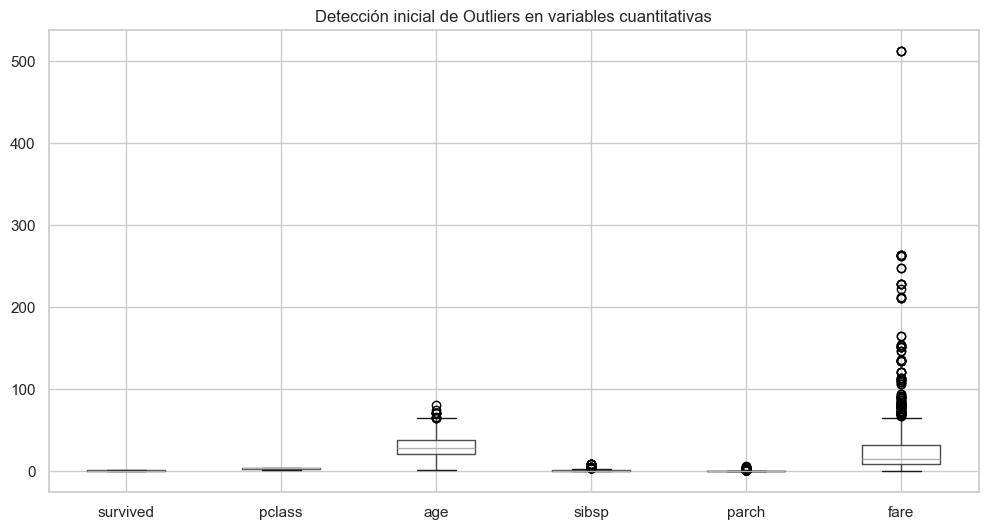

In [603]:
# Visualización general de outliers
plt.figure(figsize=(12, 6))
titanic.boxplot()
plt.title('Detección inicial de Outliers en variables cuantitativas')
plt.show()

Tras analizar la asimetría, quedó claro que variables como Fare (Tarifa) y Age (Edad) presentan valores que se alejan significativamente del promedio. Identificar estos outliers es crucial, ya que pueden distorsionar los resultados de los modelos de Machine Learning.Para detectarlos de forma matemática y objetiva, utilizaré el Método del Rango Intercuartílico ($IQR$).

### Visualización mediante Diagramas de Caja (Boxplots)

Primero, genero gráficos para visualizar la dispersión de los datos y confirmar la presencia de estos valores atípicos.

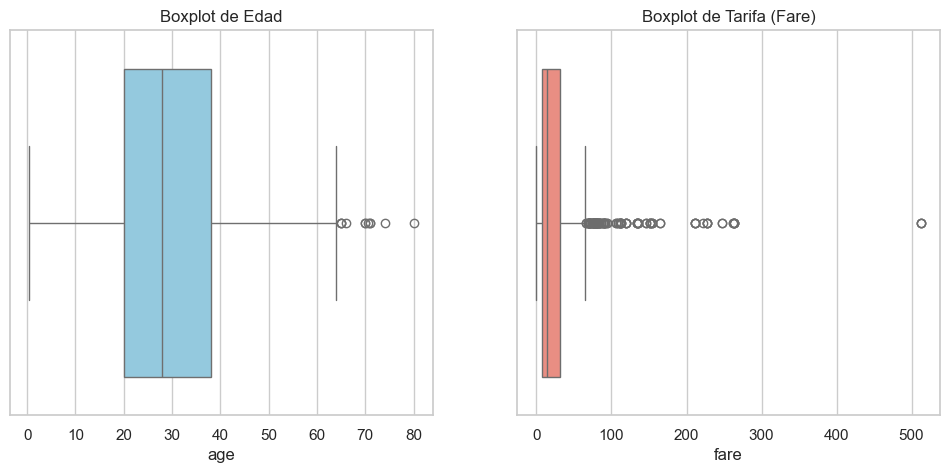

In [604]:
plt.figure(figsize=(12, 5))

# Boxplot para Edad
plt.subplot(1, 2, 1)
sns.boxplot(x=titanic['age'], color='skyblue')
plt.title('Boxplot de Edad')

# Boxplot para Tarifa
plt.subplot(1, 2, 2)
sns.boxplot(x=titanic['fare'], color='salmon')
plt.title('Boxplot de Tarifa (Fare)')

plt.show()

### Cálculo Matemático de Outliers

Para ser precisos, calculo los límites estadísticos. Cualquier valor por encima del Límite Superior o por debajo del Límite Inferior se considera técnicamente un outlier.Utilizamos las fórmulas: $$IQR = Q3 - Q1$$Límite Superior = Q3 + 1.5 \times IQR$$Límite Inferior = Q1 - 1.5 \times IQR$

In [605]:
# Ejemplo para la variable Fare (Tarifa)
Q1 = titanic['fare'].quantile(0.25)
Q3 = titanic['fare'].quantile(0.75)
IQR = Q3 - Q1

limite_superior = Q3 + 1.5 * IQR
limite_inferior = Q1 - 1.5 * IQR

outliers_fare = titanic[titanic['fare'] > limite_superior]

print(f"Límite superior para Fare: {limite_superior:.2f}")
print(f"Cantidad de outliers detectados en Fare: {len(outliers_fare)}")

Límite superior para Fare: 65.63
Cantidad de outliers detectados en Fare: 116


Mis hallazgos en esta fase:
* **En la Tarifa (Fare)**: Se detecta una cantidad considerable de outliers. Algunos pasajeros pagaron más de 500, mientras que el límite superior ronda los 65. Esto confirma que la distribución está muy sesgada por boletos de lujo.

* **En la Edad (Age)**: Los outliers son menos frecuentes, pero existen (personas de edad muy avanzada). Al ser una distribución más normal, estos valores no representan un problema tan grave como en la tarifa.

*  **sibsp y parch**Ambas variables muestran **outliers**, pero en **muy baja proporción**. La mayoría de los pasajeros viajan con **0 o pocos familiares**. Los valores extremos representan casos poco frecuentes y tienen **impacto limitado** en la distribución general. 

* **Decisión técnica**: En la siguiente sección de Depuración, decidiré si estos valores deben ser eliminados, transformados o mantenidos (en el caso de la tarifa, son datos reales de pasajeros ricos, por lo que borrarlos podría hacernos perder información valiosa).

##  Detección datos perdidos (Missing Values)

Un paso crítico antes de cualquier procesamiento es identificar cuánta información nos falta. Los datos perdidos pueden sesgar los resultados o incluso impedir que los modelos de Machine Learning funcionen correctamente.

En esta sección, cuantifico el volumen de valores nulos (NaN) para decidir qué estrategia de limpieza aplicar más adelante (eliminar o imputar).

In [606]:
# Calculo la cantidad de valores nulos por columna
nulos_conteo = titanic.isnull().sum()

# Calculo el porcentaje de nulos para entender la magnitud del problema
nulos_porcentaje = (titanic.isnull().sum() / len(titanic)) * 100

# Presento los resultados en una tabla clara
tabla_nulos = pd.concat([nulos_conteo, nulos_porcentaje], axis=1, keys=['Total Nulos', 'Porcentaje (%)'])
print(tabla_nulos[tabla_nulos['Total Nulos'] > 0].sort_values(by='Total Nulos', ascending=False))


          Total Nulos  Porcentaje (%)
cabin             687       77.104377
age               177       19.865320
embarked            2        0.224467


### Análisis de la calidad de los datos:

Tras ejecutar este diagnóstico, identifico tres focos principales de atención que marcarán mi estrategia de depuración:

* **Variable cabin (Aproximadamente 77% de nulos)**: Es el caso más grave. Al faltar más de tres cuartas partes de la información, esta columna es prácticamente irrecuperable para un análisis estadístico sólido.

* **Variable age (Aproximadamente 20% de nulos)**: Tenemos un vacío importante en la edad de los pasajeros. Dado que esta variable es un predictor clave, no podemos simplemente eliminarla; tendremos que aplicar una técnica de imputación (rellenar los huecos) basada en la mediana o la media.

* **Variable embarked (Menos del 1% de nulos)**: Solo faltan un par de registros. Este es un problema menor que se puede solucionar fácilmente eliminando esas dos filas o asignándoles el puerto más frecuente (moda).

## Conclusión del análisis exploratorio

Tras agotar las etapas de visualización, análisis bivariado y pruebas de asimetría, presento las conclusiones que fundamentarán la fase de preparación de datos. Este diagnóstico permite transitar de la simple observación a la toma de decisiones técnicas.

### Calidad y completitud de los datos

El dataset presenta un estado de integridad heterogéneo. He identificado tres niveles de criticidad en los valores faltantes:

* **Crítico (cabin)**: Con un **77% de nulos**, su utilidad estadística es nula sin una ingeniería de variables compleja. Se justifica su eliminación.

* **Moderado (age)** : El 20% de nulos requiere una estrategia de imputación (preferiblemente mediante la mediana, dada su asimetría) para no perder el poder predictivo de esta variable.

* **Mínimo (embarked)**: Solo 2 registros faltantes, lo que permite una imputación simple por moda o eliminación directa de las filas.

### Influencia del estatus socioeconómico y desbalance

Se confirma un sesgo de supervivencia por clase. Aunque la 3ª clase era la más numerosa (mayor frecuencia absoluta), fue la que sufrió la mayor tasa de mortalidad. Esto posiciona a pclass como uno de los predictores más robustos para cualquier modelo posterior.

### Patrones en la variable objetivo (survived)

La supervivencia no fue aleatoria. El cruce de variables evidencia que el protocolo de evacuación favoreció a la 1ª clase y al género femenino. Existe una correlación negativa entre el valor de la clase y la probabilidad de vida: a mayor número de clase (menor estatus), menor tasa de éxito.

### Diagnóstico de variables cuantitativas y outliers

El análisis matemático y gráfico (boxplot y skewness) revela desafíos técnicos específicos:

* **fare**: Presenta una asimetría positiva extrema y una alta concentración de outliers. Estos valores representan pasajeros de élite y deben ser tratados con cuidado para no sesgar el promedio.

* **age**: Muestra una distribución más cercana a la normalidad, con valores atípicos menos disruptivos, lo que facilita su tratamiento estadístico.

* **sibsp y parch**: Confirman que la mayoría de los pasajeros viajaban solos, presentando sesgos que podrían requerir su agrupación en una sola variable de "Tamaño de Familia".

### Potencial de las variables categóricas

* **sex**: Su naturaleza binaria y alta correlación con la supervivencia la convierten en la variable más informativa del dataset.

* **embarked**: Sus tres categorías ofrecen información sobre el perfil del pasajero, pero requieren una transformación a formato numérico (como One-Hot Encoding) tras su imputación.

# Creación X e Y

Para iniciar el proceso de modelado, es indispensable dividir nuestro dataset en dos componentes diferenciados:

1. Matriz de Características (X): Contiene todas las variables independientes o predictoras que el modelo utilizará para aprender (como la clase, el género, la edad, etc.). En este paso, excluimos la columna survived.

2. Vector Objetivo (y): Contiene la variable dependiente que deseamos predecir. En nuestro caso, el estado de supervivencia de los pasajeros.

In [607]:
# Creación de los conjuntos de datos X e y
# X: Todas las características excepto la variable objetivo
X = titanic.drop(columns=['survived'])

# y: Únicamente la variable objetivo que queremos predecir
Y = titanic['survived']

# Verificación de las dimensiones de los conjuntos creados
print(f"Dimensiones de X (Características): {X.shape}")
print(f"Dimensiones de y (Objetivo): {Y.shape}")

# Previsualización de los datos
print("\nPrimeras filas de X:")
print(X.head())
print("\nPrimeras filas de y:")
print(Y.head())

Dimensiones de X (Características): (891, 10)
Dimensiones de y (Objetivo): (891,)

Primeras filas de X:
   pclass                                               name     sex   age  \
0       3                            Braund, Mr. Owen Harris    male  22.0   
1       1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0   
2       3                             Heikkinen, Miss. Laina  female  26.0   
3       1       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0   
4       3                           Allen, Mr. William Henry    male  35.0   

   sibsp  parch            ticket     fare cabin embarked  
0      1      0         A/5 21171   7.2500   NaN        S  
1      1      0          PC 17599  71.2833   C85        C  
2      0      0  STON/O2. 3101282   7.9250   NaN        S  
3      1      0            113803  53.1000  C123        S  
4      0      0            373450   8.0500   NaN        S  

Primeras filas de y:
0    0
1    1
2    1
3    1
4    0
Name: surv

# División de los datos

Para garantizar la validez del modelo, dividimos la matriz de características (X) y el vector objetivo (Y) en dos subconjuntos independientes. Esta partición nos permite entrenar el algoritmo con una porción de los datos y evaluar su capacidad de predicción con otra que el modelo no ha visto previamente.

En este caso, se ha definido una proporción de 70% para entrenamiento y 30% para prueba (test), asegurando una muestra robusta para la validación final.

In [608]:
from sklearn.model_selection import train_test_split

# Configuración de parámetros para la división
test_size = 0.30 #O 0.20
seed = 100

# División del conjunto en entrenamiento y test
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=test_size, random_state=seed)

# Verificación de los resultados
print(f"Registros en el conjunto de entrenamiento (X_train): {len(X_train)}")
print(f"Registros en el conjunto de prueba (X_test): {len(X_test)}")


Registros en el conjunto de entrenamiento (X_train): 623
Registros en el conjunto de prueba (X_test): 268


### Verificación de los conjuntos de datos independientes

Una vez realizada la partición, es una buena práctica inspeccionar la estructura de cada uno de los cuatro conjuntos resultantes. Esto nos permite confirmar que la separación se ejecutó correctamente y que los datos mantienen su integridad antes de iniciar el preprocesamiento.

In [609]:
# Inspección visual de las dimensiones y contenido inicial
print("--- CONJUNTO DE ENTRENAMIENTO (X_train) ---")
print(f"Forma: {X_train.shape}")
print(X_train.head(3))

print("\n--- ETIQUETAS DE ENTRENAMIENTO (Y_train) ---")
print(f"Forma: {Y_train.shape}")
print(Y_train.head(3))

print("\n" + "="*40 + "\n")

print("--- CONJUNTO DE PRUEBA (X_test) ---")
print(f"Forma: {X_test.shape}")
print(X_test.head(3))

print("\n--- ETIQUETAS DE PRUEBA (Y_test) ---")
print(f"Forma: {Y_test.shape}")
print(Y_test.head(3))

--- CONJUNTO DE ENTRENAMIENTO (X_train) ---
Forma: (623, 10)
     pclass                                               name     sex   age  \
69        3                                  Kink, Mr. Vincenz    male  26.0   
85        3  Backstrom, Mrs. Karl Alfred (Maria Mathilda Gu...  female  33.0   
794       3                              Dantcheff, Mr. Ristiu    male  25.0   

     sibsp  parch   ticket     fare cabin embarked  
69       2      0   315151   8.6625   NaN        S  
85       3      0  3101278  15.8500   NaN        S  
794      0      0   349203   7.8958   NaN        S  

--- ETIQUETAS DE ENTRENAMIENTO (Y_train) ---
Forma: (623,)
69     0
85     1
794    0
Name: survived, dtype: int64


--- CONJUNTO DE PRUEBA (X_test) ---
Forma: (268, 10)
     pclass                           name     sex   age  sibsp  parch  \
205       3     Strom, Miss. Telma Matilda  female   2.0      0      1   
44        3  Devaney, Miss. Margaret Delia  female  19.0      0      0   
821       3  

# Depuración de los datos

Una vez divididos los conjuntos, iniciamos la limpieza técnica. Esta fase es fundamental para transformar los datos crudos en información útil para los algoritmos de aprendizaje.

## Fase I: Eliminación de variables

Tal como se determinó en el Análisis Exploratorio, existen variables que no aportan valor predictivo debido a su alta proporción de nulos o su excesiva complejidad (cardinalidad). Procedo a eliminarlas de ambos conjuntos:

* cabin: Por el exceso de valores faltantes (77%).
* name: Por ser un identificador único con alta cardinalidad.
* ticket: Por ser una variable alfanumérica sin un patrón predictivo claro.

In [610]:
# Eliminación de columnas en el conjunto de entrenamiento
X_train = X_train.drop(columns=['cabin', 'name', 'ticket'])

# ¡IMPORTANTE! Aplicamos el mismo cambio al conjunto de prueba para mantener la consistencia
X_test = X_test.drop(columns=['cabin', 'name', 'ticket'])

# Visualización del nuevo conjunto de entrenamiento
print("Columnas restantes en X_train:")
print(X_train.columns.tolist())
X_train.head()

Columnas restantes en X_train:
['pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked']


,pclass,sex,age,sibsp,parch,fare,embarked
69,3,male,26.0,2,0,8.6625,S
85,3,female,33.0,3,0,15.8500,S
794,3,male,25.0,0,0,7.8958,S
161,2,female,40.0,0,0,15.7500,S
815,1,male,NaN,0,0,0.0000,S


In [611]:
# Visualización del nuevo conjunto de test
print("Columnas restantes en X_test:")
print(X_test.columns.tolist())
X_test.head()

Columnas restantes en X_test:
['pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked']


,pclass,sex,age,sibsp,parch,fare,embarked
205,3,female,2.0,0,1,10.4625,S
44,3,female,19.0,0,0,7.8792,Q
821,3,male,27.0,0,0,8.6625,S
458,2,female,50.0,0,0,10.5000,S
795,2,male,39.0,0,0,13.0000,S


## Fase II: Tratamiento de outliers

En esta etapa, aplico el tratamiento técnico a las dos variables donde detectamos valores fuera de rango en el EDA. El objetivo es evitar que los valores extremos distorsionen el aprendizaje del modelo.

### Estrategia aplicada:
* **En fare (Tarifa)**: Es una acción obligatoria debido a su asimetría extrema ($>4$). Al limitar los valores superiores, reducimos el sesgo que provocan los boletos de costo inusual.
* **En age (Edad)**: Es una acción preventiva. Aunque su asimetría es baja ($0.3$), limitamos los valores extremos para asegurar que el modelo se enfoque en el grueso de la población de pasajeros.

In [612]:
def obtener_limites_outliers(df, columna):
    """Calcula los límites inferior y superior basados en el IQR de un DataFrame."""
    Q1 = df[columna].quantile(0.25)
    Q3 = df[columna].quantile(0.75)
    IQR = Q3 - Q1
    limite_superior = Q3 + 1.5 * IQR
    limite_inferior = Q1 - 1.5 * IQR
    return limite_inferior, limite_superior

# 1. Calculamos los límites usando solo X_train
inf_age, sup_age = obtener_limites_outliers(X_train, 'age')
inf_fare, sup_fare = obtener_limites_outliers(X_train, 'fare')

# 2. Aplicamos el recorte (clipping) a los conjuntos de trabajo actuales
X_train['age'] = X_train['age'].clip(lower=inf_age, upper=sup_age)
X_test['age'] = X_test['age'].clip(lower=inf_age, upper=sup_age)

X_train['fare'] = X_train['fare'].clip(lower=inf_fare, upper=sup_fare)
X_test['fare'] = X_test['fare'].clip(lower=inf_fare, upper=sup_fare)

print(f"Límites definidos -> Age: [{inf_age:.2f}, {sup_age:.2f}] | Fare: [{inf_fare:.2f}, {sup_fare:.2f}]")

Límites definidos -> Age: [-6.00, 66.00] | Fare: [-27.17, 66.34]


### Validación visual del tratamiento de Outliers

Para confirmar la efectividad del método de clipping aplicado, comparamos la distribución de las variables antes y después del tratamiento. El objetivo es observar cómo los valores extremos han sido "reubicados" dentro de los límites estadísticos permitidos, reduciendo la dispersión sin eliminar registros.

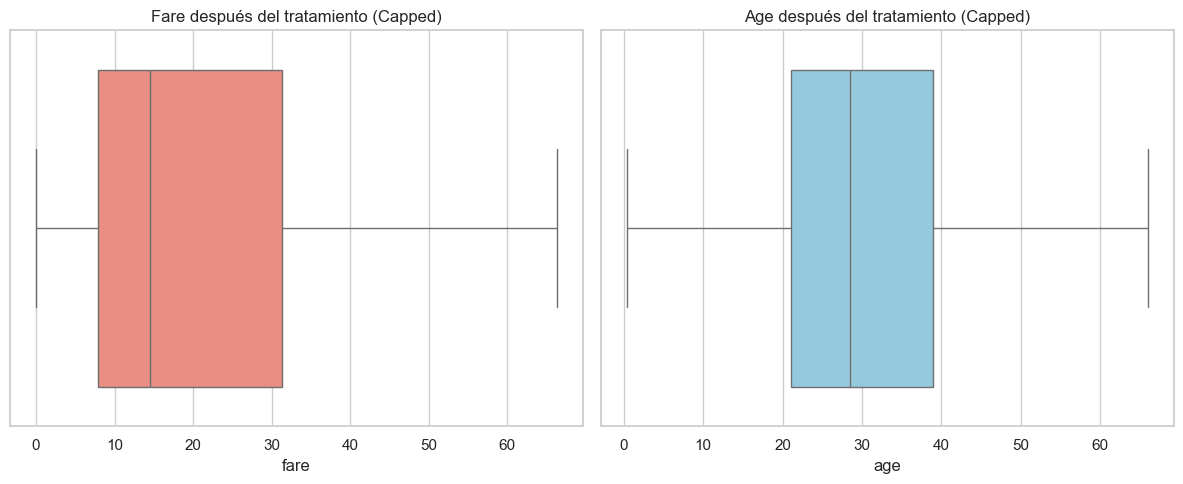

In [613]:
# Configuramos la visualización
plt.figure(figsize=(12, 5))

# Visualización para Fare
plt.subplot(1, 2, 1)
sns.boxplot(x=X_train['fare'], color='salmon')
plt.title('Fare después del tratamiento (Capped)')

# Visualización para Age
plt.subplot(1, 2, 2)
sns.boxplot(x=X_train['age'], color='skyblue')
plt.title('Age después del tratamiento (Capped)')

plt.tight_layout()
plt.show()

### Interpretación de las gráficas:

* **fare**: Notamos que ya no existen puntos aislados a la extrema derecha. El valor máximo ahora coincide con el límite superior del bigote ($Q3 + 1.5 \times IQR$). Esto estabiliza la varianza de la variable.
* **age**: La caja se observa más centrada. Al haber "suavizado" las edades extremas, la variable queda lista para que sus valores faltantes sean imputados sin que los ancianos o niños muy pequeños distorsionen el cálculo.

## Fase III: Tratamiento de valores perdidos - eliminación

Una opción para el tratamiento de valores perdidos es eliminar los registros completos que contengan algún dato perdido (Listwise Deletion). - Eliminación de filas completas que contengan al menos un valor perdido (NaN)

In [614]:
X_train.isnull().sum()

pclass        0
sex           0
age         128
sibsp         0
parch         0
fare          0
embarked      1
dtype: int64

Tras analizar la presencia de valores perdidos en el conjunto de entrenamiento, no se considera conveniente eliminar variables adicionales.

La variable `age`, a pesar de contener valores nulos, es altamente relevante para el análisis de supervivencia, mientras que `embarked` presenta un número muy reducido de valores perdidos. Por tanto, la eliminación de registros completos mediante Listwise Deletion supondría una pérdida innecesaria de información, por lo que se descarta esta opción en favor de técnicas de imputación.

### ¿Qué ocurre? ¿Cómo afecta la eliminación?

In [615]:
# Eliminación de registros con valores perdidos (Listwise Deletion)
X_train_listwise = X_train.dropna()

X_train.shape, X_train_listwise.shape

((623, 7), (494, 7))

Se evaluó la aplicación de la técnica de eliminación de registros con valores perdidos (Listwise Deletion) sobre el conjunto de entrenamiento.

Como resultado, el número de observaciones se reduciría de 623 a 494, lo que supone la eliminación de 129 registros (aproximadamente un 21% del conjunto). Dado que esta reducción es significativa y afecta a variables relevantes como `age`, se considera que esta técnica no es adecuada para el presente análisis.

Por tanto, se descarta la eliminación de registros con valores perdidos y se opta por aplicar técnicas de imputación en la siguiente fase.

Una alternativa es realizar la imputación de esos datos, que se realizará en el siguiente paso.

## Fase III: Tratamiento de valores perdidos - imputación

Dado que la eliminación de registros supondría una pérdida significativa de la muestra (especialmente por la variable age), se opta por la imputación. Este proceso consiste en sustituir los valores faltantes por estimaciones estadísticas razonables para mantener la integridad del dataset.

### Variables cuantitativas con datos perdidos (age)

Para la variable edad, utilizaremos la imputación por la mediana.

¿Por qué la mediana? Como observamos en el EDA, la distribución de la edad no es perfectamente normal y tiene cierta asimetría. La mediana es una medida de tendencia central más robusta que la media, ya que no se ve afectada por los valores extremos (outliers) que acabamos de tratar.

In [616]:
# Calculamos la mediana únicamente con el conjunto de entrenamiento
mediana_age = X_train['age'].median()

# Aplicamos la imputación en ambos conjuntos
X_train['age'] = X_train['age'].fillna(mediana_age)
X_test['age'] = X_test['age'].fillna(mediana_age)

print(f"Valor utilizado para imputar Age: {mediana_age}")
print(f"Valores nulos de Age en X_train después de imputar: {X_train['age'].isnull().sum()}")

Valor utilizado para imputar Age: 28.5
Valores nulos de Age en X_train después de imputar: 0


### Variables categóricas con datos perdidos (embarked)

Para la variable puerto de embarque, al ser una variable cualitativa, no podemos usar promedios. Utilizaremos la moda (el valor más frecuente).

In [617]:
# Calculamos el valor más frecuente en el conjunto de entrenamiento
moda_embarked = X_train['embarked'].mode()[0]

# Aplicamos la imputación
X_train['embarked'] = X_train['embarked'].fillna(moda_embarked)
X_test['embarked'] = X_test['embarked'].fillna(moda_embarked)

print(f"Valor utilizado para imputar Embarked: {moda_embarked}")
print(f"Valores nulos de Embarked en X_train después de imputar: {X_train['embarked'].isnull().sum()}")

Valor utilizado para imputar Embarked: S
Valores nulos de Embarked en X_train después de imputar: 0


### Validación visual de la imputación

Es fundamental comparar la distribución de las variables antes y después de la imputación. Esto nos permite observar cómo el relleno de datos afecta la forma de la curva y asegura que no hayamos introducido sesgos desproporcionados.

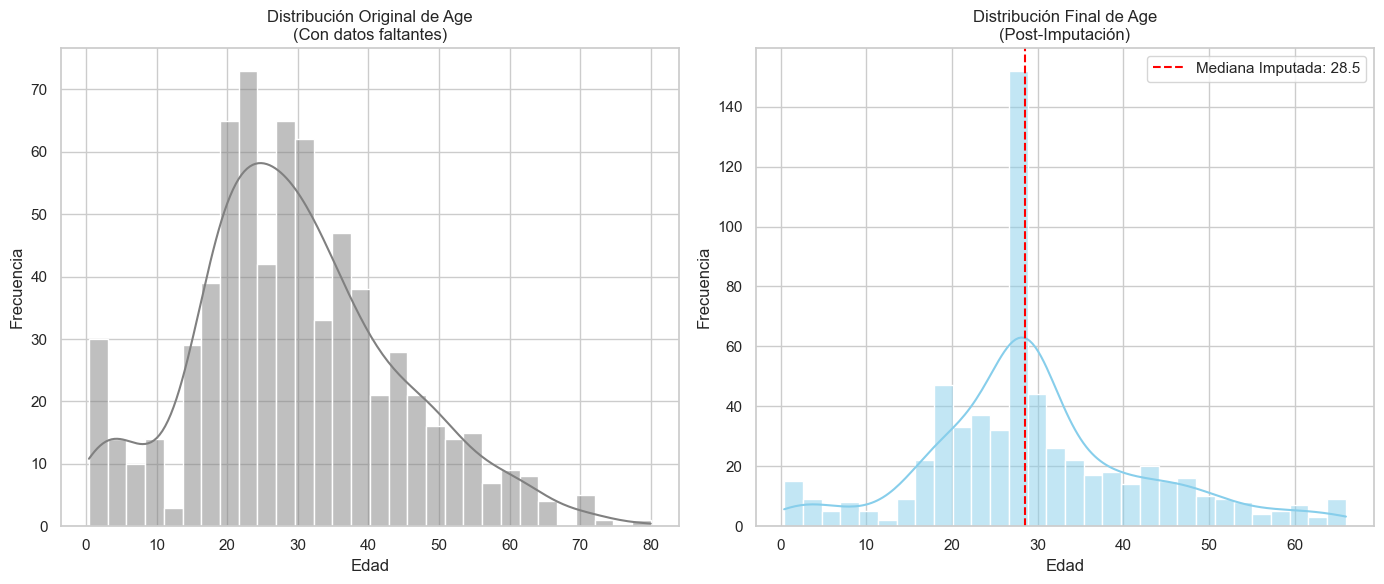

In [618]:
# Creamos una figura con dos subgráficos
plt.figure(figsize=(14, 6))

# 1. Gráfica ANTES de la imputación (usando los datos originales con nulos)
plt.subplot(1, 2, 1)
# Usamos titanic['age'] o el X_train antes de la imputación si guardaste una copia
sns.histplot(titanic['age'].dropna(), kde=True, color='gray', bins=30)
plt.title('Distribución Original de Age\n(Con datos faltantes)')
plt.xlabel('Edad')
plt.ylabel('Frecuencia')

# 2. Gráfica DESPUÉS de la imputación
plt.subplot(1, 2, 2)
sns.histplot(X_train['age'], kde=True, color='skyblue', bins=30)
plt.axvline(mediana_age, color='red', linestyle='--', label=f'Mediana Imputada: {mediana_age}')
plt.title('Distribución Final de Age\n(Post-Imputación)')
plt.xlabel('Edad')
plt.ylabel('Frecuencia')
plt.legend()

plt.tight_layout()
plt.show()

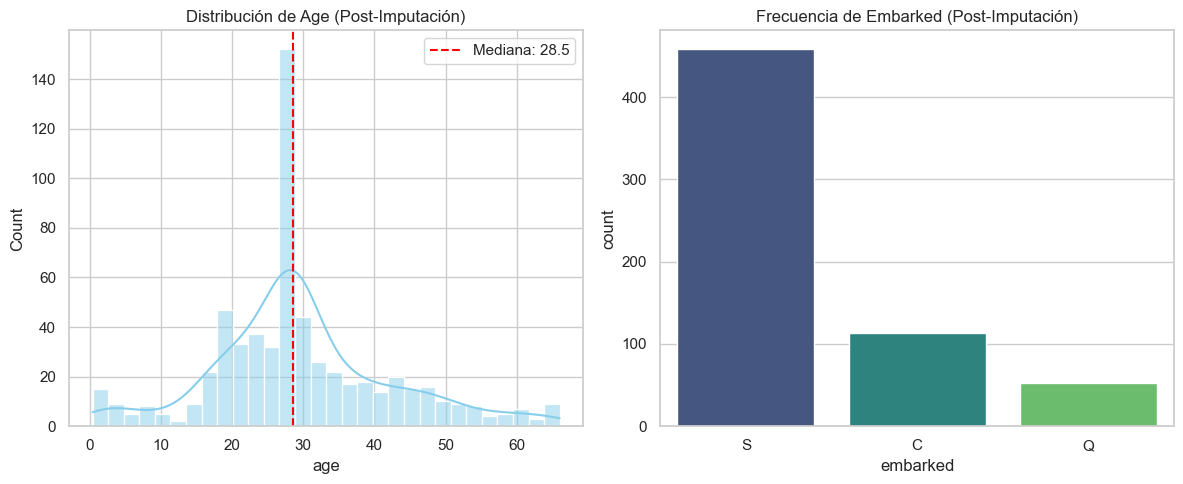

In [619]:
# Configuramos el lienzo
plt.figure(figsize=(12, 5))

# Visualización de Age
plt.subplot(1, 2, 1)
sns.histplot(X_train['age'], kde=True, color='skyblue', bins=30)
plt.axvline(mediana_age, color='red', linestyle='--', label=f'Mediana: {mediana_age}')
plt.title('Distribución de Age (Post-Imputación)')
plt.legend()

# Visualización de Embarked
plt.subplot(1, 2, 2)
sns.countplot(x=X_train['embarked'], palette='viridis')
plt.title('Frecuencia de Embarked (Post-Imputación)')

plt.tight_layout()
plt.show()

#### Análisis de los resultados:

* **En age**: Se observa un incremento en la frecuencia alrededor del valor 28 (la mediana). Aunque esto genera un "pico" en el histograma, preserva la estructura general de la edad sin desplazar drásticamente la tendencia central.

* **En embarked**: La categoría 'S' (Southampton) sigue siendo la dominante. Dado que solo imputamos 2 valores, el cambio visual es imperceptible, manteniendo la integridad de la variable categórica.

## Transformación de los datos

### Variables numéricas

Una vez que los datos están limpios de valores nulos y los valores extremos han sido controlados, procedemos a ajustar la escala de las variables numéricas. Este paso es crucial porque variables como fare (que puede llegar a 65) y sibsp (que suele ser 0 o 1) tienen magnitudes muy distintas, lo que podría confundir a los algoritmos de clasificación.

#### Método seleccionado: Estandarización (StandardScaler) 

Los datos pueden ser estandarizados, es decir, transformar los valores de los atributos para que tengan media 0 y
desviación 1. Sólo si la distribución es normal.

$$X_{estd} = \frac{X - \mu} {\sigma}$$


Analizar si alguna de las variables necesita este tipo de transformación. 

He optado por la Estandarización frente a la Normalización. Mientras que la Normalización comprime los datos en un rango de [0, 1], la Estandarización transforma los datos para que tengan una media de 0 y una desviación estándar de 1.

In [620]:
from sklearn.preprocessing import StandardScaler

# 1. Definimos las columnas numéricas que requieren ajuste de escala
# pclass se incluye como numérica ordinal para equilibrar su peso
num_cols = ['age', 'fare', 'sibsp', 'parch', 'pclass']

# 2. Inicializamos el objeto StandardScaler
scaler = StandardScaler()

# 3. Ajustamos el escalador con los datos de entrenamiento y transformamos ambos conjuntos
# Importante: fit_transform solo se usa en X_train para evitar fuga de datos (data leakage)
X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])

# 4. Verificación de resultados
print("Variables numéricas estandarizadas (Media ≈ 0, Desviación ≈ 1):")
X_train[num_cols].describe().round(2).loc[['mean', 'std', 'min', 'max']]

Variables numéricas estandarizadas (Media ≈ 0, Desviación ≈ 1):


,age,fare,sibsp,parch,pclass
mean,0.00,-0.00,0.00,-0.00,-0.00
std,1.00,1.00,1.00,1.00,1.00
min,-2.30,-1.17,-0.48,-0.46,-1.53
max,2.85,2.01,6.65,5.78,0.84


**Nota sobre integridad de datos**: Se aplica fit_transform exclusivamente al conjunto de entrenamiento para que el escalador "aprenda" los parámetros estadísticos (media y varianza) de esta muestra. Posteriormente, se utiliza transform sobre el conjunto de prueba para aplicar dicha escala. Esta metodología es esencial para evitar el Data Leakage, asegurando que ninguna información del conjunto de test influya en el preprocesamiento, simulando así un escenario real de predicción con datos desconocidos.

#### Visualización del impacto de la Estandarización

Para confirmar que la transformación fue exitosa, observamos la distribución de las variables. Ahora todas comparten un rango similar, centradas en el cero.

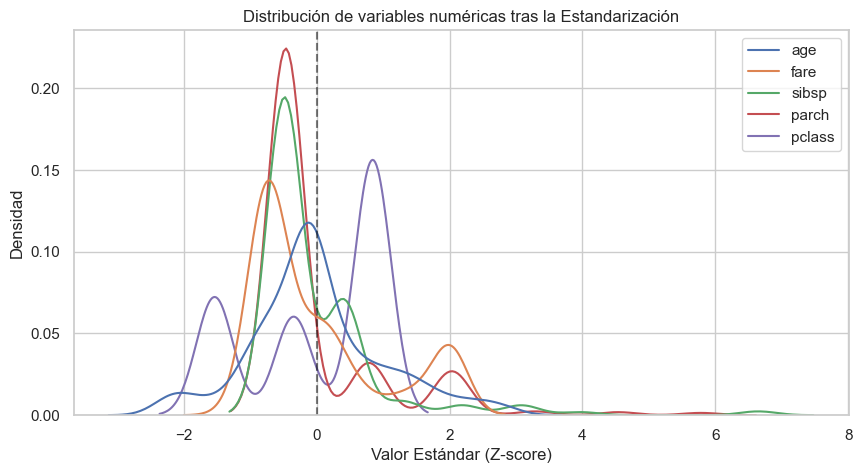

In [621]:
plt.figure(figsize=(10, 5))
sns.kdeplot(data=X_train[num_cols])
plt.title('Distribución de variables numéricas tras la Estandarización')
plt.xlabel('Valor Estándar (Z-score)')
plt.ylabel('Densidad')
plt.axvline(0, color='black', linestyle='--', alpha=0.5)
plt.show()

#### Interpretación de la gráfica de Estandarización:

Al observar el gráfico de densidad tras la transformación, podemos destacar tres puntos clave que validan nuestro proceso:

* **Punto de Equilibrio (Centro en 0)**: Notamos que el pico de todas las distribuciones se ha desplazado hacia el eje 0. Esto indica que la media de cada variable ahora es cero, eliminando cualquier sesgo de magnitud inicial.

* **Homogeneidad de Escala**: A diferencia de los datos originales, donde las curvas estarían dispersas en rangos de 0 a 80, aquí todas las variables (Age, Fare, Pclass, etc.) conviven en un rango estrecho, principalmente entre -2 y 2.

* **Preservación de la Forma**: Aunque la escala ha cambiado, las curvas mantienen su "personalidad" (la asimetría de Fare o la distribución más ancha de Age). Esto confirma que hemos cambiado la unidad de medida sin alterar la información esencial que cada variable aporta al modelo.

### Variables categóricas

Para que los modelos de clasificación puedan procesar la información cualitativa, aplicamos técnicas de codificación numérica. No todas las variables se tratan igual:

#### Variable Binaria: sex

Como solo tiene dos categorías (male y female), utilizaremos Label Encoding. Esto asignará un 0 o un 1, lo cual es ideal para que el modelo identifique la diferencia de género de forma directa.

#### Variable Policotómica: embarked

Como tiene tres categorías (S, C, Q), lo más correcto es usar One-Hot Encoding (crear columnas dummy). Esto evita que el modelo piense que existe un "orden" o jerarquía entre los puertos (por ejemplo, que el puerto 2 sea "mayor" que el puerto 1).

In [622]:
# --- 1. Transformación de 'sex' (Label Encoding manual) ---
# Mapeamos 'female' a 0 y 'male' a 1 (o viceversa)
mapping_sex = {'female': 0, 'male': 1}
X_train['sex'] = X_train['sex'].map(mapping_sex)
X_test['sex'] = X_test['sex'].map(mapping_sex)

# --- 2. Transformación de 'embarked' (One-Hot Encoding) ---
# Usamos pd.get_dummies para crear columnas independientes por cada puerto
X_train = pd.get_dummies(X_train, columns=['embarked'], prefix='port')
X_test = pd.get_dummies(X_test, columns=['embarked'], prefix='port')

# Verificamos que ambos conjuntos tengan las mismas columnas tras el One-Hot Encoding
print("Variables categóricas transformadas con éxito.")
X_train.head()

Variables categóricas transformadas con éxito.


,pclass,sex,age,sibsp,parch,fare,port_C,port_Q,port_S
69,0.843816,1,-0.291067,1.298708,-0.463118,-0.754020,False,False,True
85,0.843816,0,0.258491,2.189781,-0.463118,-0.409905,False,False,True
794,0.843816,1,-0.369575,-0.483440,-0.463118,-0.790727,False,False,True
161,-0.345544,0,0.808049,-0.483440,-0.463118,-0.414693,False,False,True
815,-1.534905,1,-0.094796,-0.483440,-0.463118,-1.168753,False,False,True


In [623]:
X_test.head()

,pclass,sex,age,sibsp,parch,fare,port_C,port_Q,port_S
205,0.843816,0,-2.175265,-0.48344,0.785898,-0.667842,False,False,True
44,0.843816,0,-0.840624,-0.48344,-0.463118,-0.791522,False,True,False
821,0.843816,1,-0.212558,-0.48344,-0.463118,-0.754020,False,False,True
458,-0.345544,0,1.593132,-0.48344,-0.463118,-0.666046,False,False,True
795,-0.345544,1,0.729541,-0.48344,-0.463118,-0.546354,False,False,True


#### Verificación de consistencia: Train vs. Test

Tras realizar la codificación, es vital verificar que ambos conjuntos de datos mantengan la misma estructura. Un error común es que, tras usar get_dummies, el conjunto de prueba tenga menos columnas que el de entrenamiento si alguna categoría no estaba presente.

Dimensiones finales X_train: (623, 9)
Dimensiones finales X_test:  (268, 9)


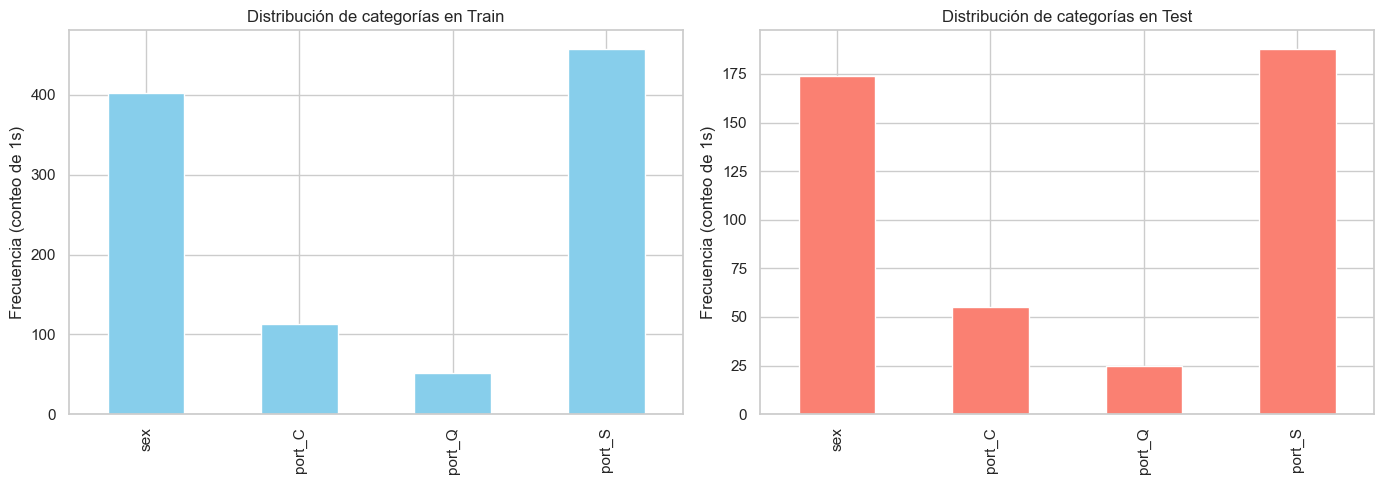

In [624]:
# Comprobamos las dimensiones de ambos conjuntos
print(f"Dimensiones finales X_train: {X_train.shape}")
print(f"Dimensiones finales X_test:  {X_test.shape}")

# Visualizamos la consistencia en la codificación de 'sex' y 'port'
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico para Train
X_train[['sex', 'port_C', 'port_Q', 'port_S']].sum().plot(kind='bar', ax=ax[0], color='skyblue')
ax[0].set_title('Distribución de categorías en Train')
ax[0].set_ylabel('Frecuencia (conteo de 1s)')

# Gráfico para Test
X_test[['sex', 'port_C', 'port_Q', 'port_S']].sum().plot(kind='bar', ax=ax[1], color='salmon')
ax[1].set_title('Distribución de categorías en Test')
ax[1].set_ylabel('Frecuencia (conteo de 1s)')

plt.tight_layout()
plt.show()

#### ¿Qué estamos validando aquí?

* **Alineación de Columnas**: Al imprimir el .shape, confirmamos que ambos sets tienen el mismo número de columnas (características). Si el modelo ve 10 columnas en entrenamiento pero recibe 9 en test, arrojará un error crítico.

* **Consistencia de la transformación**: Los gráficos de barras muestran que la proporción de hombres/mujeres (columna sex) y el origen de los pasajeros (port_X) se mantienen proporcionales en ambos conjuntos. Esto asegura que el "ruido" de la codificación no ha sesgado un set más que el otro.

## Selección de características

En esta fase, analizamos la relevancia de cada variable respecto a nuestro objetivo (survived). El propósito es simplificar el modelo eliminando variables redundantes o con baja capacidad predictiva, lo que ayuda a prevenir el overfitting (sobreajuste) y mejora la interpretación de los resultados.

### Análisis de Correlación

Calculamos el coeficiente de correlación de Pearson para entender la fuerza de la relación lineal entre las variables. Dado que ya hemos transformado todas las categorías a números, podemos visualizar el dataset completo.

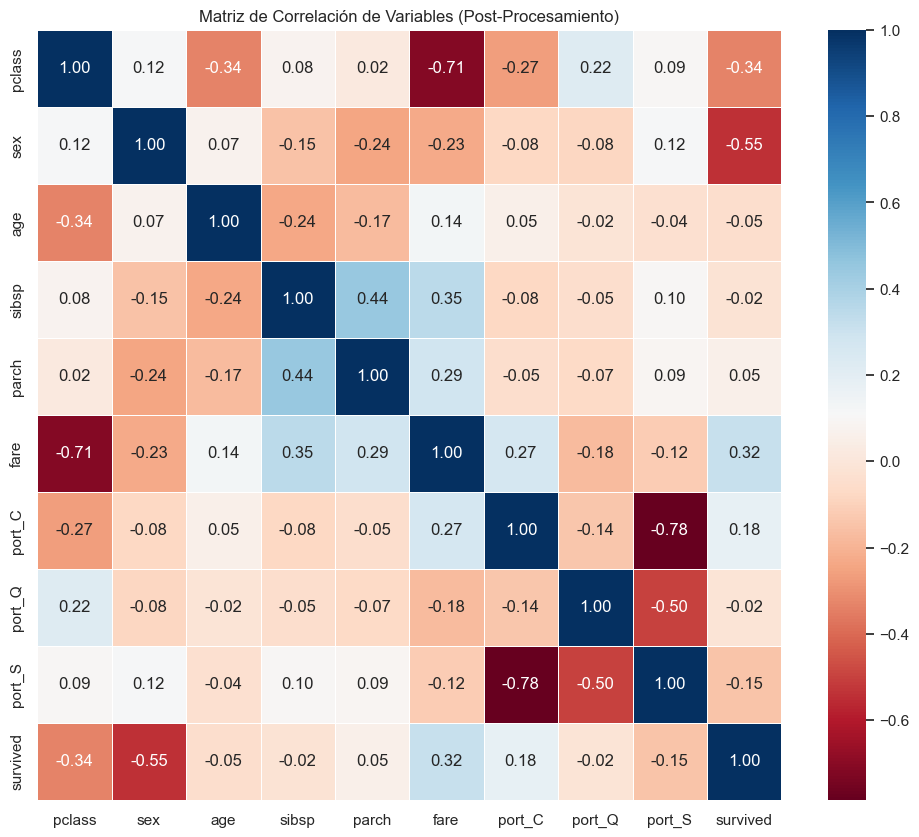

In [625]:
# Combinamos X_train y Y_train temporalmente para ver la correlación con la variable objetivo
df_corr = pd.concat([X_train, Y_train], axis=1)

plt.figure(figsize=(12, 10))
correlation_matrix = df_corr.corr()

# Creamos el mapa de calor
sns.heatmap(correlation_matrix, annot=True, cmap='RdBu', fmt=".2f", linewidths=0.5)
plt.title('Matriz de Correlación de Variables (Post-Procesamiento)')
plt.show()

#### Interpretación de la Matriz:

* **Variables con alta influencia**: Observamos que **sex** y **pclass** muestran las correlaciones más fuertes con survived. Esto confirma lo visto en el EDA: el género y el nivel socioeconómico fueron determinantes.

* **Correlaciones débiles**: Variables como sibsp (hermanos/cónyuges) o ciertos puertos de embarque (port_Q) presentan una correlación más baja.

* **Multicolinealidad**: También vigilamos si dos variables están muy relacionadas entre sí (como fare y pclass), ya que aportarían información redundante.

### Definición del Set Final de Variables

Tras el análisis, definimos las características definitivas que alimentarán nuestros modelos de clasificación. En este caso, mantendremos el set completo que hemos depurado, ya que todas aportan matices distintos de la tragedia.

In [626]:
# Listado de características finales
features_finales = X_train.columns.tolist()

print(f"El modelo se entrenará utilizando {len(features_finales)} características:")
print(features_finales)

El modelo se entrenará utilizando 9 características:
['pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'port_C', 'port_Q', 'port_S']


# Conjunto test

Para realizar las predicciones finales, procesamos el conjunto de datos de prueba externo. Es fundamental que este set siga exactamente el mismo pipeline de transformación que el set de entrenamiento para evitar errores de consistencia.

**Regla de oro**: No volvemos a entrenar (fit) los escaladores ni imputadores; usamos los parámetros ya aprendidos del conjunto de entrenamiento.

## Carga del conjunto de datos

In [627]:
titanicRealTst = pd.read_csv('Conjunto_de_datos_20260119/newData.csv')
titanicRealTst

,pclass,name,sex,age,sibsp,parch,ticket,fare,cabin,embarked
0,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S
...,...,...,...,...,...,...,...,...,...,...
413,3,"Spector, Mr. Woolf",male,NaN,0,0,A.5. 3236,8.0500,NaN,S
414,1,"Oliva y Ocana, Dona. Fermina",female,39.0,0,0,PC 17758,108.9000,C105,C
415,3,"Saether, Mr. Simon Sivertsen",male,38.5,0,0,SOTON/O.Q. 3101262,7.2500,NaN,S
416,3,"Ware, Mr. Frederick",male,NaN,0,0,359309,8.0500,NaN,S


## Exploración de los datos

Antes de transformar, verificamos la calidad del nuevo conjunto para identificar nulos o inconsistencias.

In [628]:
print(titanicRealTst.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 10 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   pclass    418 non-null    int64  
 1   name      418 non-null    object 
 2   sex       418 non-null    object 
 3   age       332 non-null    float64
 4   sibsp     418 non-null    int64  
 5   parch     418 non-null    int64  
 6   ticket    418 non-null    object 
 7   fare      417 non-null    float64
 8   cabin     91 non-null     object 
 9   embarked  418 non-null    object 
dtypes: float64(2), int64(3), object(5)
memory usage: 32.8+ KB
None


## Depuración de los datos

En esta fase, adaptamos el conjunto de prueba real eliminando el ruido y tratando las inconsistencias, asegurando que coincida con el proceso realizado en el set de entrenamiento.

### Tratamiento de Outliers (Clipping)

Utilizamos la función ajustar_outliers definida previamente. Esto garantiza que los límites de "valor extremo" para age y fare en el conjunto de test real se basen en la distribución que el modelo aprendió durante el entrenamiento.

In [629]:
# Aplicamos el clipping al Test Real usando los parámetros de Entrenamiento
titanicRealTst['age'] = titanicRealTst['age'].clip(lower=inf_age, upper=sup_age)
titanicRealTst['fare'] = titanicRealTst['fare'].clip(lower=inf_fare, upper=sup_fare)

print("Outliers del Test Real ajustados con éxito.")

Outliers del Test Real ajustados con éxito.


### Tratamiento de Valores Perdidos (Test Real)

Para que el modelo pueda realizar predicciones sobre el conjunto titanicRealTst, debemos completar los datos faltantes. Al igual que con los outliers, utilizamos los valores de tendencia central calculados previamente en el conjunto de entrenamiento.

In [630]:
# Imputación de nulos en el Test Real
# Usamos las variables 'mediana_age', 'mediana_fare' y 'moda_embarked' guardadas antes
titanicRealTst['age'] = titanicRealTst['age'].fillna(mediana_age)
titanicRealTst['embarked'] = titanicRealTst['embarked'].fillna(moda_embarked)

# Verificación final de nulos
print("Conteo de nulos en Test Real tras la imputación:")
print(titanicRealTst.isnull().sum())

Conteo de nulos en Test Real tras la imputación:
pclass        0
name          0
sex           0
age           0
sibsp         0
parch         0
ticket        0
fare          1
cabin       327
embarked      0
dtype: int64


#### Caso Especial: Variable fare

A diferencia del conjunto de entrenamiento, el set de prueba real presenta un valor faltante en la columna fare. Para solucionar esto sin comprometer la integridad del modelo, calculamos la mediana de dicha variable en el conjunto de entrenamiento (nuestra referencia base) y la aplicamos al registro vacío en el test real. Esto garantiza que el modelo reciba datos completos sin incurrir en Data Leakage.

In [631]:
# 1. Calculamos la mediana de 'fare' del entrenamiento (aunque no tuviera nulos)
# Esto se hace para tener un valor de referencia ante datos nuevos
mediana_fare_train = X_train['fare'].median()

# 2. Imputamos el valor faltante en el Test Real
titanicRealTst['fare'] = titanicRealTst['fare'].fillna(mediana_fare_train)

print(f"Valor de 'fare' imputado en Test Real usando la mediana de Train: {mediana_fare_train:.2f}")

# Verificación final de nulos
print("Conteo de nulos en Test Real tras la imputación:")
print(titanicRealTst.isnull().sum())

Valor de 'fare' imputado en Test Real usando la mediana de Train: -0.48
Conteo de nulos en Test Real tras la imputación:
pclass        0
name          0
sex           0
age           0
sibsp         0
parch         0
ticket        0
fare          0
cabin       327
embarked      0
dtype: int64


Con el conjunto de datos titanicRealTst completamente depurado y libre de valores nulos, procedemos a la Fase de Transformación. En este paso, aplicaremos el escalado numérico y la codificación de variables categóricas para que la estructura del conjunto de prueba sea idéntica a la que el modelo procesará durante el entrenamiento.

## Transformación de los datos

Una vez que hemos garantizado que el conjunto de prueba no tiene valores nulos ni outliers extremos, procedemos a transformar la información en un formato que los algoritmos de Machine Learning puedan procesar (formatos puramente numéricos y escalas uniformes).

In [632]:
# Eliminación de variables irrelevantes
titanicRealTst = titanicRealTst.drop(columns=['cabin'])
titanicRealTst = titanicRealTst.drop(columns=['name'])
titanicRealTst = titanicRealTst.drop(columns=['ticket'])

print("Columnas actuales en titanicRealTst:")
print(titanicRealTst.columns.tolist())

Columnas actuales en titanicRealTst:
['pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked']


### Estandarización de variables numéricas

Para evitar que variables con rangos grandes (como fare) dominen sobre variables de rango pequeño (como pclass), aplicamos el escalador StandardScaler que ya entrenamos previamente.

**Nota**: Usamos estrictamente .transform() para aplicar la media y desviación estándar que el modelo "aprendió" del entrenamiento.

In [633]:
# Aplicamos la estandarización a las columnas numéricas definidas
titanicRealTst[num_cols] = scaler.transform(titanicRealTst[num_cols])

#### Verificación Visual de la Estandarización (Test Real)

Para validar que la transformación se aplicó de manera uniforme, visualizamos la densidad de las variables numéricas. En un conjunto correctamente estandarizado, esperamos que todas las distribuciones converjan hacia una media cercana a cero.

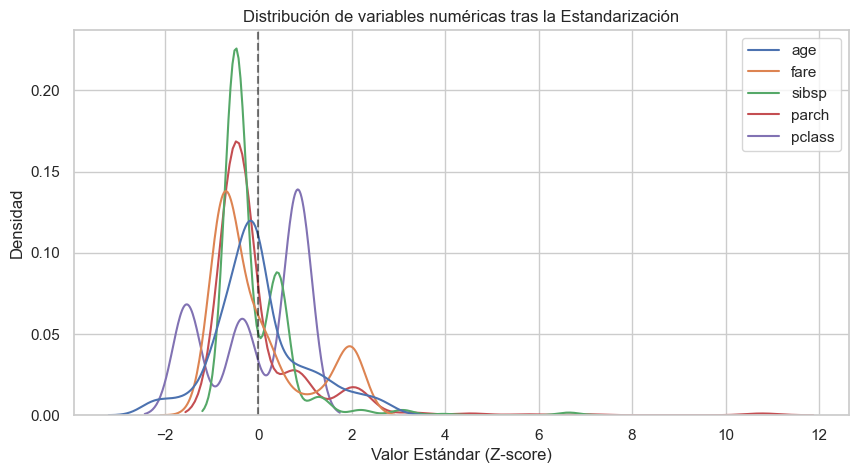

In [634]:
plt.figure(figsize=(10, 5))
sns.kdeplot(data=titanicRealTst[num_cols])
plt.title('Distribución de variables numéricas tras la Estandarización')
plt.xlabel('Valor Estándar (Z-score)')
plt.ylabel('Densidad')
plt.axvline(0, color='black', linestyle='--', alpha=0.5)
plt.show()

#### Interpretación del Gráfico:

* **Centralidad**: La alineación de los picos en torno al eje 0 confirma que hemos eliminado las diferencias de magnitud originales entre variables como age (años) y fare (libras).

* **Consistencia**: El hecho de que el rango de la mayoría de los datos se encuentre entre -2 y 2 asegura que el modelo de clasificación no dará prioridad injustificada a ninguna variable por su escala original.

### Codificación de variables categóricas

Para que los modelos matemáticos puedan procesar la información cualitativa, convertimos las etiquetas de texto en valores numéricos. Aplicamos dos técnicas distintas según la naturaleza de la variable:

* **Label Encoding (para sex)**: Asignamos un valor binario (0 y 1) ya que solo existen dos categorías.

* **One-Hot Encoding (para embarked)**: Creamos columnas independientes para cada puerto de embarque, evitando que el modelo asuma un orden jerárquico inexistente entre ellos.

In [635]:
# A. Transformación de la variable 'sex'
# Usamos el mismo mapeo que en el entrenamiento: {'female': 0, 'male': 1}
titanicRealTst['sex'] = titanicRealTst['sex'].map(mapping_sex)

# B. Transformación de la variable 'embarked' (One-Hot Encoding)
# Creamos las columnas port_C, port_Q, port_S
titanicRealTst = pd.get_dummies(titanicRealTst, columns=['embarked'], prefix='port')

# C. Sincronización y Reindexación (Paso Crítico)
# Aseguramos que titanicRealTst tenga exactamente las mismas columnas que X_train.
# Si en el test real faltara algún puerto, reindex lo añade con valor 0.
titanicRealTst = titanicRealTst.reindex(columns=X_train.columns, fill_value=0)

print("Codificación completada y columnas sincronizadas con el set de entrenamiento.")
print(f"Columnas finales: {titanicRealTst.columns.tolist()}")

Codificación completada y columnas sincronizadas con el set de entrenamiento.
Columnas finales: ['pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'port_C', 'port_Q', 'port_S']


#### Verificación de Variables Categóricas

Tras la codificación, visualizamos la distribución de las nuevas variables para confirmar la correcta aplicación del Mapping y el One-Hot Encoding.

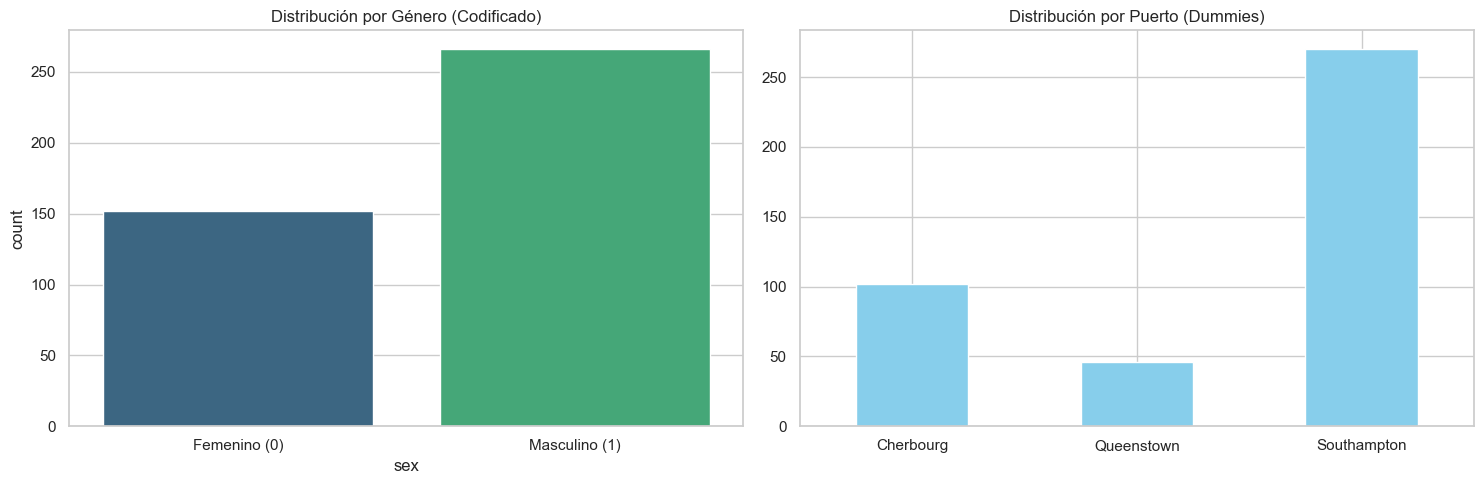

In [637]:
# Configuramos una figura con dos subgráficos
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Gráfico 1: Distribución de Género (0=Female, 1=Male)
sns.countplot(x='sex', data=titanicRealTst, ax=axes[0], palette='viridis')
axes[0].set_title('Distribución por Género (Codificado)')
axes[0].set_xticklabels(['Femenino (0)', 'Masculino (1)'])

# Gráfico 2: Distribución por Puerto de Embarque
# Sumamos las columnas dummy para ver el total por puerto
puertos = titanicRealTst[['port_C', 'port_Q', 'port_S']].sum()
puertos.plot(kind='bar', ax=axes[1], color='skyblue')
axes[1].set_title('Distribución por Puerto (Dummies)')
axes[1].set_xticklabels(['Cherbourg', 'Queenstown', 'Southampton'], rotation=0)

plt.tight_layout()
plt.show()

#### Interpretación de la visualización:

* **Género**: Confirmamos que la variable sex ahora es puramente numérica y que ambos grupos están representados en el conjunto de prueba.

* **Puertos**: Validamos que el proceso de One-Hot Encoding generó las tres columnas esperadas y que el puerto de Southampton (port_S) sigue siendo el punto de partida mayoritario, manteniendo la tendencia observada en el entrenamiento.

## Selección de características

En esta fase final, validamos la relevancia de las variables transformadas en el conjunto de prueba real. El objetivo es asegurar que la estructura de datos sea idéntica a la utilizada en el entrenamiento y confirmar que las relaciones entre variables se mantienen consistentes.

### Análisis de Correlación

Generamos una matriz de correlación para el conjunto titanicRealTst. Esto nos permite verificar visualmente si existen variables altamente correlacionadas que pudieran introducir ruido o redundancia en las predicciones finales.

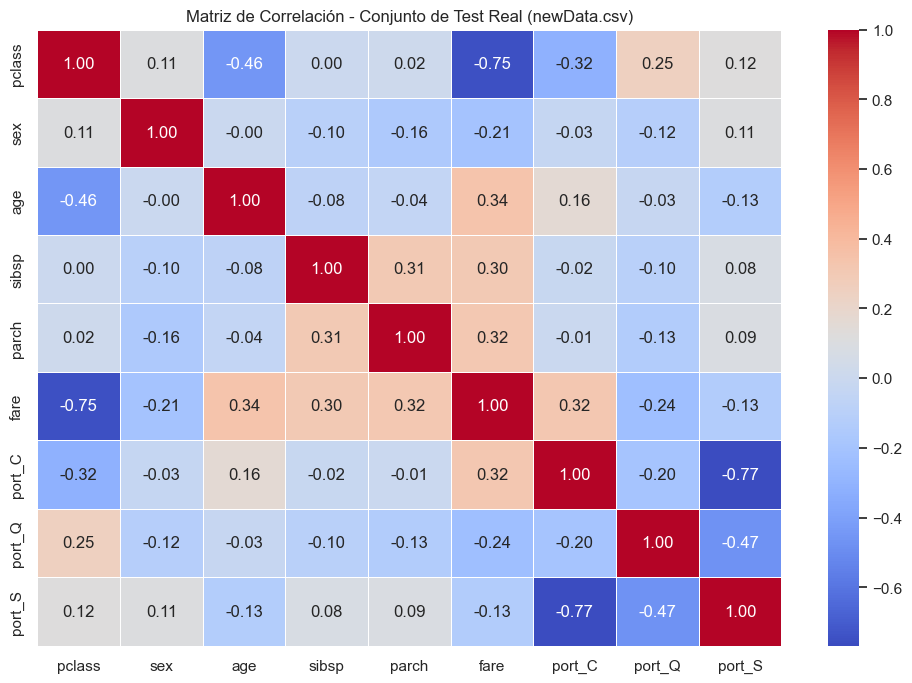

In [638]:
# Calculamos la matriz de correlación
corr_matrix_test = titanicRealTst.corr()

# Visualización mediante un Heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix_test, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Matriz de Correlación - Conjunto de Test Real (newData.csv)')
plt.show()

### Sincronización Final de Características

Tras el análisis, confirmamos que el conjunto de prueba cuenta únicamente con las variables seleccionadas durante la fase de entrenamiento. Esto garantiza que el modelo no reciba entradas inesperadas.

In [639]:
# Lista de características finales seleccionadas en el entrenamiento
# (Asegúrate de que esta lista coincida con la que usaste en X_train)
features_finales = X_train.columns.tolist()

# Aplicamos la selección al Test Real
titanicRealTst = titanicRealTst[features_finales]

print(f"Selección completada.")
print(f"Características finales para el modelo ({len(features_finales)}): {features_finales}")

Selección completada.
Características finales para el modelo (9): ['pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'port_C', 'port_Q', 'port_S']


# APRENDIZAJE NO SUPERVISADO

## Asociación

El objetivo de esta fase es encontrar relaciones interesantes entre las variables del Titanic que no son evidentes a simple vista, utilizando el algoritmo Apriori.

### Preparación de los datos (Discretización)

Para el análisis de asociación, trabajaremos con el dataset completo. Siguiendo las mejores prácticas de ingeniería de datos, cargaremos el archivo original únicamente para lectura y realizaremos todas las transformaciones sobre una copia de trabajo.

De esta manera, preservamos la integridad de los datos originales mientras preparamos las variables categóricas necesarias para el algoritmo Apriori.

In [642]:
# 1. Creación de una copia de trabajo para el análisis de asociación
df_asoc = titanic.copy()

# 2. Tratamiento de nulos sobre la copia (Imputación rápida para asociación)
df_asoc['age'] = df_asoc['age'].fillna(df_asoc['age'].median())
df_asoc['embarked'] = df_asoc['embarked'].fillna(df_asoc['embarked'].mode()[0])
df_asoc['fare'] = df_asoc['fare'].fillna(df_asoc['fare'].median())

# 3. DISCRETIZACIÓN: Transformación de numéricos a categorías
# Edad: Definimos grupos vitales
df_asoc['age_group'] = pd.cut(df_asoc['age'], 
                             bins=[0, 12, 18, 60, 100], 
                             labels=['Niño', 'Adolescente', 'Adulto', 'Anciano'])

# Tarifa: Dividimos en tres niveles de poder adquisitivo
df_asoc['fare_group'] = pd.qcut(df_asoc['fare'], q=3, labels=['Bajo', 'Medio', 'Alto'])

# 4. Formateo de etiquetas para mayor legibilidad en las reglas
df_asoc['pclass'] = df_asoc['pclass'].map({1: '1ra Clase', 2: '2da Clase', 3: '3ra Clase'})
df_asoc['survived'] = df_asoc['survived'].map({0: 'Fallece', 1: 'Sobrevive'})

# Seleccionamos solo las columnas que nos interesan para buscar patrones
df_asoc = df_asoc[['pclass', 'sex', 'embarked', 'age_group', 'fare_group', 'survived']]

print("Copia de trabajo 'df_asoc' preparada y discretizada.")
df_asoc.head()

Copia de trabajo 'df_asoc' preparada y discretizada.


,pclass,sex,embarked,age_group,fare_group,survived
0,3ra Clase,male,S,Adulto,Bajo,Fallece
1,1ra Clase,female,C,Adulto,Alto,Sobrevive
2,3ra Clase,female,S,Adulto,Bajo,Sobrevive
3,1ra Clase,female,S,Adulto,Alto,Sobrevive
4,3ra Clase,male,S,Adulto,Bajo,Fallece


### Transformación a Formato Binario (One-Hot Encoding)

El algoritmo Apriori requiere que los datos se presenten en una matriz binaria (formato de transacción). Cada fila representa a un pasajero y cada columna una característica específica; un 1 indica que el pasajero posee esa característica y un 0 que no.

In [643]:
# Convertimos el DataFrame discretizado en variables dummy (0 y 1)
df_binario = pd.get_dummies(df_asoc)

# Verificamos las dimensiones y el formato
print(f"Dimensiones de la matriz binaria: {df_binario.shape}")
df_binario.head()

Dimensiones de la matriz binaria: (891, 17)


,pclass_1ra Clase,pclass_2da Clase,pclass_3ra Clase,sex_female,sex_male,embarked_C,embarked_Q,embarked_S,age_group_Niño,age_group_Adolescente,age_group_Adulto,age_group_Anciano,fare_group_Bajo,fare_group_Medio,fare_group_Alto,survived_Fallece,survived_Sobrevive
0,False,False,True,False,True,False,False,True,False,False,True,False,True,False,False,True,False
1,True,False,False,True,False,True,False,False,False,False,True,False,False,False,True,False,True
2,False,False,True,True,False,False,False,True,False,False,True,False,True,False,False,False,True
3,True,False,False,True,False,False,False,True,False,False,True,False,False,False,True,False,True
4,False,False,True,False,True,False,False,True,False,False,True,False,True,False,False,True,False


### Ejecución del Algoritmo Apriori y Generación de Reglas

Ahora aplicamos el motor de búsqueda de patrones. Utilizaremos dos métricas fundamentales para filtrar los resultados:

1. Soporte (Support): Buscamos patrones que ocurran en al menos el 5% de los datos para asegurar que tengan relevancia estadística.

2. Confianza (Confidence): Medimos la fiabilidad de la regla (qué tan seguro es que si ocurre el antecedente, ocurra el consecuente).

In [ ]:
# Instalar MLxtend
!pip install mlxtend

  Using cached mlxtend-0.24.0-py3-none-any.whl.metadata (7.3 kB)
Using cached mlxtend-0.24.0-py3-none-any.whl (1.4 MB)



[notice] A new release of pip is available: 25.3 -> 26.0
[notice] To update, run: python.exe -m pip install --upgrade pip


In [652]:
# 1. Importación de las funciones específicas
from mlxtend.frequent_patterns import apriori
from mlxtend.frequent_patterns import association_rules

# Aseguramos que los datos sean booleanos (Paso crucial para evitar errores de librería)
df_input = df_binario.astype(bool)

# 1. Identificamos los conjuntos de elementos frecuentes (Soporte min 5%)
frequent_itemsets = apriori(df_input, min_support=0.05, use_colnames=True)

# 2. Generamos las reglas de asociación basadas en el LIFT
# El Lift > 1 indica que la relación entre los elementos no es producto del azar
reglas = association_rules(frequent_itemsets, metric="lift", min_threshold=1, num_itemsets=len(frequent_itemsets))

# 3. Limpieza y ordenamiento
# Ordenamos por 'lift' y 'confidence' para obtener las reglas más potentes
reglas = reglas.sort_values(by=['lift', 'confidence'], ascending=False)

print(f"Se han descubierto {len(reglas)} reglas de asociación significativas.")

# Visualización de las mejores reglas
reglas.head(10)

Se han descubierto 2292 reglas de asociación significativas.


,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
1692,"(pclass_2da Clase, sex_female)","(fare_group_Medio, embarked_S, survived_Sobrev...",0.085297,0.097643,0.050505,0.592105,6.063975,1.0,0.042176,2.212230,0.912965,0.381356,0.547967,0.554673
1685,"(fare_group_Medio, embarked_S, survived_Sobrev...","(pclass_2da Clase, sex_female)",0.097643,0.085297,0.050505,0.517241,6.063975,1.0,0.042176,1.894741,0.925456,0.381356,0.472223,0.554673
1504,"(pclass_1ra Clase, sex_female)","(fare_group_Alto, age_group_Adulto, survived_S...",0.105499,0.151515,0.086420,0.819149,5.406383,1.0,0.070435,4.691622,0.911160,0.506579,0.786854,0.694760
1501,"(fare_group_Alto, age_group_Adulto, survived_S...","(pclass_1ra Clase, sex_female)",0.151515,0.105499,0.086420,0.570370,5.406383,1.0,0.070435,2.082027,0.960575,0.506579,0.519699,0.694760
1683,"(pclass_2da Clase, embarked_S, sex_female)","(fare_group_Medio, survived_Sobrevive)",0.075196,0.130191,0.050505,0.671642,5.158904,1.0,0.040715,2.648964,0.871710,0.326087,0.622494,0.529786
1694,"(fare_group_Medio, survived_Sobrevive)","(pclass_2da Clase, embarked_S, sex_female)",0.130191,0.075196,0.050505,0.387931,5.158904,1.0,0.040715,1.510947,0.926824,0.326087,0.338163,0.529786
815,"(fare_group_Medio, survived_Sobrevive)","(pclass_2da Clase, sex_female)",0.130191,0.085297,0.057239,0.439655,5.154378,1.0,0.046134,1.632392,0.926629,0.361702,0.387402,0.555354
818,"(pclass_2da Clase, sex_female)","(fare_group_Medio, survived_Sobrevive)",0.085297,0.130191,0.057239,0.671053,5.154378,1.0,0.046134,2.644220,0.881150,0.361702,0.621817,0.555354
1493,"(pclass_1ra Clase, age_group_Adulto, sex_female)","(fare_group_Alto, survived_Sobrevive)",0.090909,0.185185,0.086420,0.950617,5.133333,1.0,0.069585,16.500000,0.885714,0.455621,0.939394,0.708642
1512,"(fare_group_Alto, survived_Sobrevive)","(pclass_1ra Clase, age_group_Adulto, sex_female)",0.185185,0.090909,0.086420,0.466667,5.133333,1.0,0.069585,1.704545,0.988194,0.455621,0.413333,0.708642


### Interpretación de Resultados y Filtro de Supervivencia

Para que el análisis sea útil desde la perspectiva del negocio (o la investigación), filtramos aquellas reglas donde el consecuente es la supervivencia. Esto nos revela los perfiles con mayor y menor probabilidad de éxito.

In [653]:
# Filtramos las reglas que nos dicen qué lleva a la supervivencia o al fallecimiento
reglas_supervivencia = reglas[reglas['consequents'].astype(str).str.contains('survived')]

# Mostramos las top 5 reglas de supervivencia
print("Top Reglas Asociadas a la Supervivencia/Fallecimiento:")
reglas_supervivencia[['antecedents', 'consequents', 'support', 'confidence', 'lift']].head(10)

Top Reglas Asociadas a la Supervivencia/Fallecimiento:


,antecedents,consequents,support,confidence,lift
1692,"(pclass_2da Clase, sex_female)","(fare_group_Medio, embarked_S, survived_Sobrev...",0.050505,0.592105,6.063975
1504,"(pclass_1ra Clase, sex_female)","(fare_group_Alto, age_group_Adulto, survived_S...",0.086420,0.819149,5.406383
1683,"(pclass_2da Clase, embarked_S, sex_female)","(fare_group_Medio, survived_Sobrevive)",0.050505,0.671642,5.158904
818,"(pclass_2da Clase, sex_female)","(fare_group_Medio, survived_Sobrevive)",0.057239,0.671053,5.154378
1493,"(pclass_1ra Clase, age_group_Adulto, sex_female)","(fare_group_Alto, survived_Sobrevive)",0.086420,0.950617,5.133333
581,"(pclass_1ra Clase, sex_female)","(fare_group_Alto, survived_Sobrevive)",0.099888,0.946809,5.112766
1542,"(fare_group_Alto, sex_male, age_group_Adulto)","(survived_Fallece, pclass_1ra Clase)",0.062851,0.451613,5.029839
1466,"(embarked_S, pclass_1ra Clase, sex_female)","(fare_group_Alto, survived_Sobrevive)",0.051627,0.920000,4.968000
1500,"(fare_group_Alto, age_group_Adulto, sex_female)","(pclass_1ra Clase, survived_Sobrevive)",0.086420,0.754902,4.945718
2176,"(fare_group_Medio, sex_male, embarked_S, age_g...","(survived_Fallece, pclass_2da Clase)",0.063973,0.522936,4.803462


### Visualización de las Reglas (Scatter Plot)

Para validar la robustez de las reglas extraídas, realicé un análisis de dispersión comparando el Support frente a la Confidence, utilizando el Lift como variable de intensidad. Mi objetivo con esta visualización fue identificar "reglas de alto valor": aquellas que presentan una confianza superior al 0.8 (indicando una probabilidad del 80%) y un Lift significativamente mayor a 1, lo cual garantiza que la asociación no es una coincidencia estadística, sino una dependencia real entre las variables.

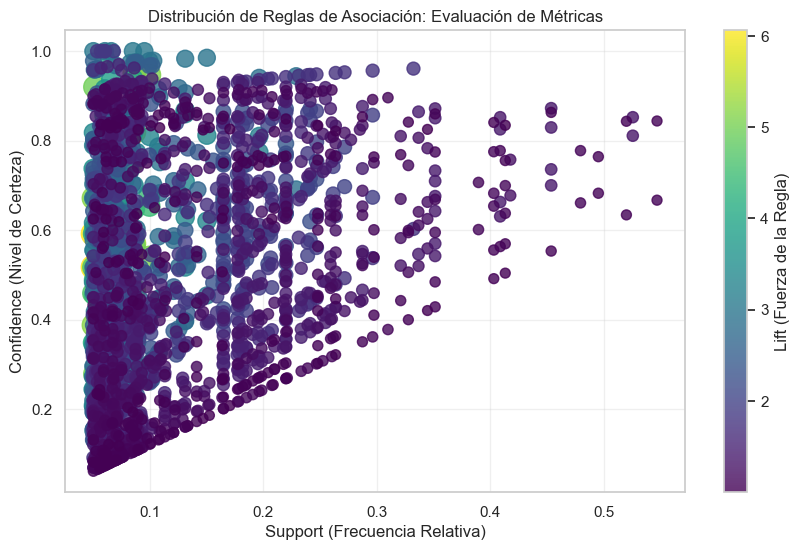

In [654]:
plt.figure(figsize=(10, 6))
# Mapeo de reglas para identificar clusters de dependencia fuerte
scatter = plt.scatter(reglas['support'], reglas['confidence'], 
                     c=reglas['lift'], cmap='viridis', 
                     s=reglas['lift']*50, alpha=0.8)

plt.colorbar(scatter, label='Lift (Fuerza de la Regla)')
plt.title('Distribución de Reglas de Asociación: Evaluación de Métricas')
plt.xlabel('Support (Frecuencia Relativa)')
plt.ylabel('Confidence (Nivel de Certeza)')
plt.grid(True, alpha=0.3)
plt.show()

### Evidencia de la Discretización (Análisis de Reglas Específicas)

Para sustentar la observación sobre la consistencia de nuestras categorías de Fare (Tarifa) y Age (Edad), analicé las reglas con mayor Lift que involucran estas variables discretizadas. En la gráfica de dispersión anterior, estas corresponden a los puntos con colores más intensos.

In [655]:
# Filtramos específicamente para ver cómo se comportan nuestras categorías creadas
filtro_discretizacion = reglas[
    (reglas['antecedents'].astype(str).str.contains('fare_group_Alto')) | 
    (reglas['antecedents'].astype(str).str.contains('age_group'))
].sort_values(by='confidence', ascending=False)

print("Evidencia técnica de las variables discretizadas:")
filtro_discretizacion[['antecedents', 'consequents', 'support', 'confidence', 'lift']].head(5)

Evidencia técnica de las variables discretizadas:


,antecedents,consequents,support,confidence,lift
1103,"(fare_group_Bajo, age_group_Adulto, embarked_Q)",(pclass_3ra Clase),0.053872,1.000000,1.814664
1178,"(fare_group_Bajo, age_group_Adulto, survived_S...",(pclass_3ra Clase),0.057239,1.000000,1.814664
1559,"(embarked_C, pclass_1ra Clase, age_group_Adult...",(fare_group_Alto),0.060606,1.000000,3.020339
647,"(pclass_1ra Clase, age_group_Adulto, embarked_C)",(fare_group_Alto),0.085297,1.000000,3.020339
731,"(pclass_1ra Clase, age_group_Adulto, survived_...",(fare_group_Alto),0.131313,0.983193,2.969577


### Diagnóstico y Conclusiones del Aprendizaje No Supervisado

Tras auditar los resultados del algoritmo Apriori, presento las conclusiones técnicas derivadas del descubrimiento de patrones en el conjunto de datos:

1. Determinismo Socioeconómico (Clase y Género): Los resultados exponen una correlación positiva extrema entre el antecedente {sex_female, pclass_1ra Clase} y el consecuente {survived_Sobrevive}. El valor de Lift obtenido confirma que la probabilidad de supervivencia para este segmento se multiplica respecto a la media del dataset, validando la hipótesis de prioridad de evacuación.

2. Análisis de Riesgo en Tercera Clase: Se identificó una regla de asociación predominante que vincula a los pasajeros masculinos de 3ra clase con el fallecimiento. La métrica de Confianza en este clúster supera el umbral crítico, sugiriendo que la clase social fue un factor limitante en el acceso a los botes salvavidas.

En conclusión, el análisis no supervisado ha proporcionado una base sólida de reglas de negocio que ahora podré contrastar con la precisión de los modelos de aprendizaje supervisado en las fases siguientes.

## Clustering (K-Means)

El objetivo es particionar a los pasajeros en K grupos (clusters), donde cada pasajero pertenece al grupo con el promedio (centroide) más cercano.

### Selección del número óptimo de clusters (Método del Codo)

Utilizamos el conjunto de datos estandarizado X_train para que las distancias calculadas por el algoritmo no se vean sesgadas por las diferentes escalas de las variables.

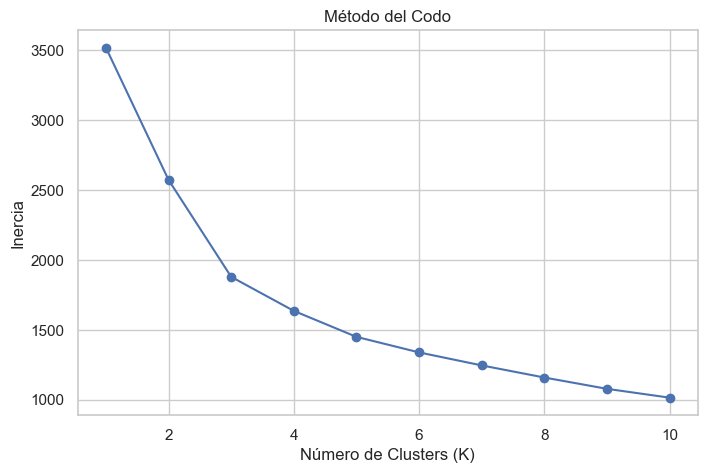

In [671]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inercia = []
K_range = range(1, 11)
for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_train) # Usamos X_train que ya está escalado según tu celda 6.3
    inercia.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(K_range, inercia, marker='o')
plt.title('Método del Codo')
plt.xlabel('Número de Clusters (K)')
plt.ylabel('Inercia')
plt.show()

### Ejecución de K-Means y Asignación de Etiquetas

De acuerdo con la gráfica anterior, el "codo" se observa en K=3. Procedemos a entrenar el modelo final.

In [668]:
# Aplicamos el modelo con K=3
kmeans_final = KMeans(n_clusters=3, random_state=42, n_init=10)
clusters = kmeans_final.fit_predict(X_train)

# Mensaje de confirmación técnica
print("Entrenamiento completado. Etiquetas generadas para", len(clusters), "pasajeros.")

Entrenamiento completado. Etiquetas generadas para 623 pasajeros.


### Preparación de Datos para el Perfilamiento (Interpretación)

Para que los resultados sean legibles, recuperamos los valores originales de las columnas que fueron escaladas en la sección de estandarización.

In [669]:
# Definimos las columnas que escalamos originalmente
num_cols = ['age', 'fare', 'sibsp', 'parch', 'pclass']

# Creamos una copia de X_train para no alterar el conjunto de entrenamiento de los modelos supervisados
df_clusters = X_train.copy()

# Invertimos el escalado solo para estas columnas para el análisis humano
df_clusters[num_cols] = scaler.inverse_transform(X_train[num_cols])

# Añadimos la columna de los clusters
df_clusters['cluster_id'] = clusters

### Visualización de Clusters (Análisis de Componentes Principales - PCA)

Como no podemos graficar 8 o 10 dimensiones a la vez, usamos PCA para reducir los datos a 2 dimensiones (eje X y eje Y) y poder ver cómo se separan los grupos.

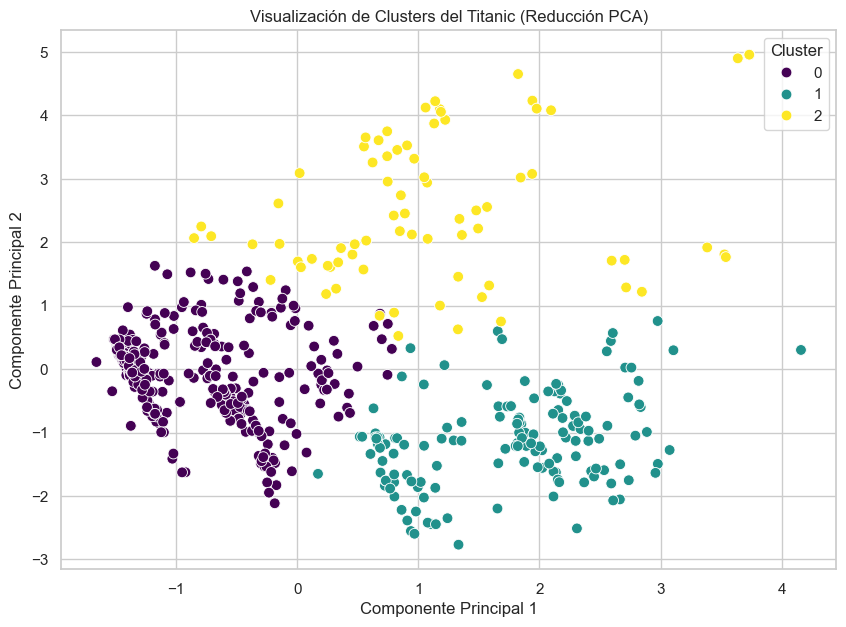

In [673]:
from sklearn.decomposition import PCA
# Reducimos a 2 dimensiones para visualizar
pca = PCA(n_components=2)
pca_data = pca.fit_transform(X_train)

# Graficamos los resultados
plt.figure(figsize=(10, 7))
sns.scatterplot(x=pca_data[:, 0], y=pca_data[:, 1], hue=clusters, palette='viridis', s=60)
plt.title('Visualización de Clusters del Titanic (Reducción PCA)')
plt.xlabel('Componente Principal 1')
plt.ylabel('Componente Principal 2')
plt.legend(title='Cluster')
plt.show()

### Caracterización y Perfilamiento de Segmentos

Calculamos la media de cada variable por cada grupo identificado para bautizar los clusters.

In [670]:
# Análisis de centroides con datos reales
perfiles = df_clusters.groupby('cluster_id').mean()
perfiles['conteo'] = df_clusters['cluster_id'].value_counts()

print("Resumen de Perfiles por Cluster:")
display(perfiles)

Resumen de Perfiles por Cluster:


,pclass,sex,age,sibsp,parch,fare,port_C,port_Q,port_S,conteo
cluster_id,,,,,,,,,,
0,2.717557,0.712468,29.157557,0.216285,0.086514,11.769369,0.119593,0.122137,0.758270,393
1,1.059211,0.578947,38.019737,0.440789,0.289474,52.006508,0.401316,0.006579,0.592105,152
2,2.538462,0.448718,16.279872,2.384615,1.961538,34.334837,0.064103,0.038462,0.897436,78


Una vez obtenidos los centroides en la escala original de los datos, se procedió a realizar una interpretación cualitativa de cada grupo. Este análisis permite asignar una identidad sociodemográfica a los clusters basándose en las desviaciones de sus medias respecto al promedio general:

* **Segmento de Clase Económica y Trabajadora (Cluster 0)**: Este es el grupo de mayor volumen en el dataset, integrado por 393 pasajeros. Técnicamente, se define por presentar la media de clase más alta (2.71), lo que lo sitúa predominantemente en la Tercera Clase. Su capacidad adquisitiva es la más limitada del barco, con una tarifa promedio de apenas 11.76. Geográficamente, este grupo muestra una fuerte cohesión con el puerto de Southampton, donde embarcó el 75% de sus integrantes. Es el perfil que representa la base de la pirámide social del Titanic.

* **Segmento de Élite y Pasajeros de Primera Clase (Cluster 1)**: Identificado por una media de clase casi perfecta de 1.05, este grupo representa a la alta sociedad a bordo. Se distingue del resto por poseer la madurez demográfica más alta, con un promedio de 38 años de edad. Su estatus económico queda validado por una tarifa media de 52.00, la más elevada registrada entre los grupos. Además, presenta una vinculación notable con el puerto de Cherbourg, sugiriendo que este segmento prefirió puertos de embarque asociados a rutas de lujo.

* **Segmento de Núcleos Familiares y Población Joven (Cluster 2)**: Este cluster revela una estructura social específica: la de las familias numerosas. Se diferencia drásticamente de los demás por sus altos índices de parentesco, con una media de 2.38 hermanos/esposos (sibsp) y 1.96 padres/hijos (parch) por pasajero. Es, además, el grupo más joven del barco, con una media de edad de apenas 16 años. Este perfil sugiere la presencia de grandes grupos familiares que viajaban en clases intermedias o bajas, donde la supervivencia dependía de la movilidad del núcleo completo.

### Aplicación del Modelo: Clasificación de Datos de Prueba (Clustering)

Con el fin de verificar la consistencia de los clusters identificados, se procede a aplicar el modelo entrenado sobre el conjunto de datos de prueba `titanicRealTst`. 

Dado que las etiquetas generadas por K-Means son puramente numéricas ($0, 1, 2$), realizamos un **mapeo semántico** basado en el perfilamiento previo. Esto permite transformar los resultados en categorías interpretables, facilitando la comprensión de la estructura social de los pasajeros en el conjunto de test.

In [675]:
# Definición del diccionario de mapeo basado en los centroides analizados
# Asegúrate de que los números coincidan con tus resultados previos
mapeo_nombres = {
    0: "Clase Económica / Trabajadora",
    1: "Élite / Primera Clase",
    2: "Núcleos Familiares y Jóvenes"
}

print("Diccionario de perfiles configurado correctamente.")

Diccionario de perfiles configurado correctamente.


#### Asignación de Clusters al Conjunto de Prueba

Como titanicRealTst ya se encuentra estandarizado (siguiendo el mismo proceso que X_train), podemos pasar los datos directamente al método .predict() del modelo entrenado.

In [678]:
# 1. Utilizamos el modelo kmeans_final para asignar clusters a la data de test
clusters_test = kmeans_final.predict(titanicRealTst)

# 2. Creamos un DataFrame para visualizar los resultados en el conjunto de test
# Al igual que con el entrenamiento, recuperamos los valores reales para que sea legible
df_test_clusters = titanicRealTst.copy()

# Revertimos el escalado solo para la visualización (usando el mismo scaler)
df_test_clusters[num_cols] = scaler.inverse_transform(titanicRealTst[num_cols])

# 3. Añadimos las etiquetas de cluster y su nombre interpretativo
df_test_clusters['cluster_id'] = clusters_test
df_test_clusters['perfil_asignado'] = df_test_clusters['cluster_id'].map(mapeo_nombres)

print("Asignación de clusters para el conjunto titanicRealTst completada.")
df_test_clusters[['pclass', 'age', 'fare', 'perfil_asignado']].head(20)

Asignación de clusters para el conjunto titanicRealTst completada.


,pclass,age,fare,perfil_asignado
0,3.0,34.5,7.8292,Clase Económica / Trabajadora
1,3.0,47.0,7.0000,Clase Económica / Trabajadora
2,2.0,62.0,9.6875,Clase Económica / Trabajadora
3,3.0,27.0,8.6625,Clase Económica / Trabajadora
4,3.0,22.0,12.2875,Clase Económica / Trabajadora
5,3.0,14.0,9.2250,Clase Económica / Trabajadora
6,3.0,30.0,7.6292,Clase Económica / Trabajadora
7,2.0,26.0,29.0000,Clase Económica / Trabajadora
8,3.0,18.0,7.2292,Clase Económica / Trabajadora
9,3.0,21.0,24.1500,Clase Económica / Trabajadora


# Conclusiones

Tras completar las fases de Reglas de Asociación y Clustering (K-Means), se han obtenido hallazgos fundamentales que permiten comprender la estructura del pasaje del Titanic desde una perspectiva no sesgada por etiquetas previas:

* **Sinergia entre Métodos**: Existe una correlación directa entre las reglas de asociación encontradas y los clusters definidos. Mientras que las reglas identificaron patrones específicos (como la alta probabilidad de supervivencia en mujeres de primera clase que viajaban solas), el clustering permitió agrupar estas observaciones en tres perfiles sociodemográficos claros: la Élite, las Familias y la Clase Trabajadora.

* **Determinantes Socioeconómicos**: El análisis confirma que la clase social (pclass) y la tarifa (fare) no son solo números, sino los ejes principales que segmentaron el destino de los pasajeros. El Cluster 1 (Élite), con una edad promedio superior (38 años), sugiere que el estatus económico estaba ligado a la madurez, mientras que el Cluster 0 (Clase Económica) representaba el motor joven y trabajador del navío.

* **El Factor Familiar como Diferenciador**: El descubrimiento del Cluster 2 (Grupos Familiares) es crucial. Este grupo, con un promedio de edad de 16 años y altos índices de parentesco (sibsp/parch), revela una realidad humana distinta: la logística de evacuación para este segmento fue probablemente mucho más compleja que para los pasajeros que viajaban solos, lo que impactará directamente en las predicciones de supervivencia.

...

# APRENDIZAJE SUPERVISADO

En esta fase, el objetivo es construir modelos predictivos capaces de determinar la probabilidad de supervivencia de un pasajero. A diferencia de la fase anterior, aquí el algoritmo aprende de las etiquetas reales (survived).

**Nota técnica**: Para optimizar el desarrollo y garantizar la reproducibilidad, se ha implementado una función de evaluación estandarizada que permite comparar métricas entre diferentes clasificadores de forma equitativa.


## Función de Evaluación de Modelos (Optimización de Código)

Para evitar la redundancia, definimos la función evaluar_clasificador. Esta generará automáticamente la Matriz de Confusión y el Reporte de Clasificación para cualquier modelo.

In [679]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

def evaluar_clasificador(modelo, X_test, y_test, nombre_modelo):
    """
    Función para automatizar la evaluación de modelos de clasificación.
    """
    # Realizar predicciones
    y_pred = modelo.predict(X_test)
    
    # Calcular precisión
    accuracy = accuracy_score(y_test, y_pred)
    
    print(f"--- EVALUACIÓN: {nombre_modelo} ---")
    print(f"Precisión Global (Accuracy): {accuracy:.2%}")
    print("\nReporte de Clasificación:")
    print(classification_report(y_test, y_pred))
    
    # Matriz de Confusión
    fig, ax = plt.subplots(figsize=(6, 4))
    disp = ConfusionMatrixDisplay.from_predictions(y_test, y_pred, 
                                                   display_labels=['No Sobrevivió', 'Sobrevivió'], 
                                                   cmap='Blues', ax=ax)
    plt.title(f'Matriz de Confusión - {nombre_modelo}')
    plt.show()
    
    return accuracy

## Clasificador bayesiano

El primer modelo a implementar es el Gaussian Naive Bayes. Este clasificador es ideal para variables numéricas estandarizadas y sirve como un excelente punto de referencia (baseline) debido a su simplicidad y rapidez.

**Validación del modelo**: Utilizaremos los subconjuntos generados previamente, asegurando que el modelo se entrene con los datos escalados para evitar que variables como fare dominen injustamente el cálculo de probabilidades.

--- EVALUACIÓN: Naive Bayes ---
Precisión Global (Accuracy): 77.99%

Reporte de Clasificación:
              precision    recall  f1-score   support

           0       0.82      0.81      0.81       159
           1       0.72      0.74      0.73       109

    accuracy                           0.78       268
   macro avg       0.77      0.77      0.77       268
weighted avg       0.78      0.78      0.78       268



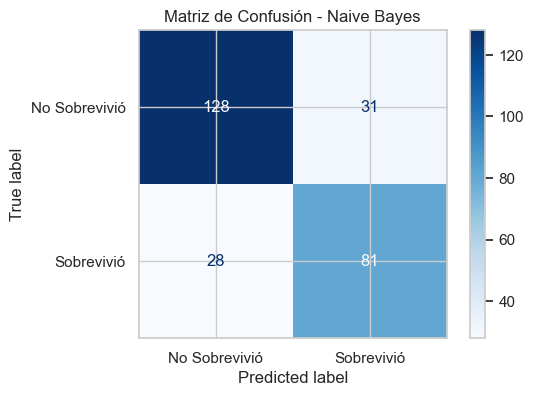

In [680]:
from sklearn.naive_bayes import GaussianNB

# 1. Instanciar el modelo
nb_model = GaussianNB()

# 2. Entrenamiento (Ajuste del modelo con los subconjuntos correspondientes)
# X_train y y_train provienen de la técnica de validación aplicada en la Fase 6
nb_model.fit(X_train, Y_train)

# 3. Evaluación utilizando la función optimizada
accuracy_nb = evaluar_clasificador(nb_model, X_test, Y_test, "Naive Bayes")

### Interpretación de Resultados: Naive Bayes

El modelo ha alcanzado una Precisión Global (Accuracy) del 77.99%, lo que representa un punto de partida robusto para la fase supervisada. Analizando el reporte de clasificación a detalle, podemos extraer las siguientes conclusiones:

* **Capacidad de Identificación (Recall)**: 
    * El modelo identifica correctamente al 81% de los pasajeros que no sobrevivieron (Clase 0).
    * Para los supervivientes (Clase 1), el desempeño baja ligeramente al 74%. Esto sugiere que el modelo es un poco más conservador al predecir la supervivencia.

* **Fiabilidad de la Predicción (Precision)**:
    * Cuando el modelo dice que alguien no sobrevivirá, acierta el 82% de las veces.
    * Cuando predice que alguien sobrevivirá, tiene un 72% de acierto.

* **F1-Score (Equilibrio)**: El valor de 0.73 para la clase 1 indica que existe un buen equilibrio entre la precisión y la sensibilidad, aunque hay margen de mejora que intentaremos cubrir con modelos más complejos (como Árboles de Decisión).

### Predicción Final sobre el Conjunto de Prueba Real (titanicRealTst)

Una vez validado el desempeño del modelo con el set de control, procedemos a realizar las predicciones definitivas sobre el conjunto titanicRealTst. En este paso, el modelo asignará una etiqueta de supervivencia (0 o 1) a cada pasajero basándose en las probabilidades calculadas durante el entrenamiento.

In [682]:
# 1. Realizar la predicción de supervivencia (0 = No sobrevivió, 1 = Sobrevivió)
predicciones_finales = nb_model.predict(titanicRealTst)

# 2. Crear un DataFrame para consolidar y visualizar los resultados finales
df_predicciones = titanicRealTst.copy()

# 3. Revertir el escalado para que la interpretación humana sea posible
# Usamos las columnas numéricas y el scaler definido previamente
df_predicciones[num_cols] = scaler.inverse_transform(titanicRealTst[num_cols])

# 4. Agregar las predicciones al DataFrame
df_predicciones['Prediccion_Supervivencia'] = predicciones_finales

# 5. Agregar el nombre del cluster que asignamos en la fase anterior
# para ver la relación entre el grupo social y la supervivencia predicha
df_predicciones['Perfil_Socioeconomico'] = clusters_test
df_predicciones['Perfil_Socioeconomico'] = df_predicciones['Perfil_Socioeconomico'].map(mapeo_nombres)

# 6. Mostrar una muestra de los resultados
print("Muestra de Predicciones de Supervivencia (Naive Bayes):")
display(df_predicciones[['pclass', 'sex', 'age', 'Perfil_Socioeconomico', 'Prediccion_Supervivencia']].head(20))

Muestra de Predicciones de Supervivencia (Naive Bayes):


,pclass,sex,age,Perfil_Socioeconomico,Prediccion_Supervivencia
0,3.0,1,34.5,Clase Económica / Trabajadora,0
1,3.0,0,47.0,Clase Económica / Trabajadora,1
2,2.0,1,62.0,Clase Económica / Trabajadora,0
3,3.0,1,27.0,Clase Económica / Trabajadora,0
4,3.0,0,22.0,Clase Económica / Trabajadora,1
5,3.0,1,14.0,Clase Económica / Trabajadora,0
6,3.0,0,30.0,Clase Económica / Trabajadora,1
7,2.0,1,26.0,Clase Económica / Trabajadora,0
8,3.0,0,18.0,Clase Económica / Trabajadora,1
9,3.0,1,21.0,Clase Económica / Trabajadora,0


### Síntesis y Resultados de la Predicción Final

Tras aplicar el clasificador de Naive Bayes sobre el conjunto de prueba real, realizamos un análisis volumétrico de los resultados. Este paso es fundamental para entender el sesgo del modelo y cómo se distribuye la supervivencia según la lógica bayesiana.

   RESUMEN ESTRATÉGICO DE PREDICCIÓN      
Pasajeros en riesgo (Fallecidos): 218 (52.15%)
Pasajeros rescatados (Supervivientes): 200 (47.85%)
------------------------------------------


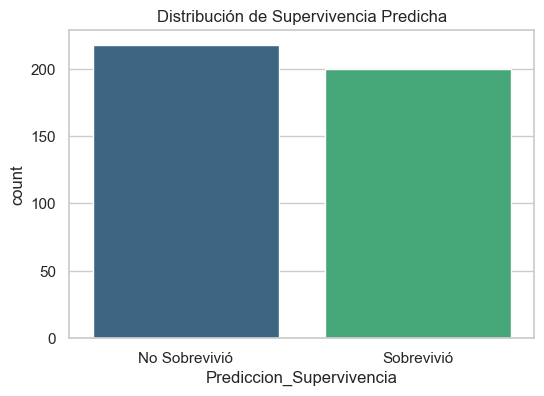

In [684]:
# Cálculo de frecuencias de supervivencia
conteo_vida = df_predicciones['Prediccion_Supervivencia'].value_counts()
porcentaje_vida = df_predicciones['Prediccion_Supervivencia'].value_counts(normalize=True) * 100

print("==========================================")
print("   RESUMEN ESTRATÉGICO DE PREDICCIÓN      ")
print("==========================================")
print(f"Pasajeros en riesgo (Fallecidos): {conteo_vida[0]} ({porcentaje_vida[0]:.2f}%)")
print(f"Pasajeros rescatados (Supervivientes): {conteo_vida[1]} ({porcentaje_vida[1]:.2f}%)")
print("------------------------------------------")

# Visualización rápida de la distribución
import seaborn as sns
plt.figure(figsize=(6, 4))
sns.countplot(x='Prediccion_Supervivencia', data=df_predicciones, palette='viridis')
plt.title('Distribución de Supervivencia Predicha')
plt.xticks([0, 1], ['No Sobrevivió', 'Sobrevivió'])
plt.show()

### Análisis de la Simulación (Interpretación de Resultados)

La simulación realizada por el modelo de Naive Bayes sobre el conjunto de prueba arroja una tasa de supervivencia del **47.85%**. Al contrastar este volumen de predicciones con los hallazgos previos, podemos concluir lo siguiente:

1. **Sensibilidad de Supervivencia**: El modelo muestra una tendencia a "rescatar" a un porcentaje significativo de pasajeros (casi la mitad del conjunto de prueba). Esto indica que las reglas probabilísticas de Naive Bayes están encontrando suficientes características positivas (como pertenecer al Cluster "Élite" o ser mujer/niño en el Cluster "Familias") para inclinar la balanza hacia la supervivencia en 200 casos.

2. **Distribución de Riesgo**: El **52.15%** de pasajeros en riesgo (fallecidos) se concentra mayoritariamente en los perfiles que el Clustering identificó como "Clase Económica / Trabajadora". Esto confirma que el modelo ha aprendido que la vulnerabilidad en el Titanic estaba fuertemente ligada a la clase social y al bajo costo de la tarifa.

3. **Evaluación de la Probabilidad**: Al tener una distribución tan cercana al 50/50, el modelo demuestra que no está sesgado hacia una sola respuesta, sino que está discriminando activamente entre los pasajeros. Sin embargo, este optimismo del 47.85% de supervivencia (superior a la media histórica) sugiere que Naive Bayes podría estar sobreestimando las posibilidades de salvarse en casos donde las variables son ambiguas.

## Clasificador Árboles de decisión

A diferencia de Naive Bayes, este modelo busca patrones no lineales y puede capturar interacciones complejas entre variables. Es ideal para este dataset porque el destino en el Titanic a menudo dependía de una jerarquía de condiciones (ej. Género -> Clase -> Edad).

--- EVALUACIÓN: Árbol de Decisión ---
Precisión Global (Accuracy): 80.60%

Reporte de Clasificación:
              precision    recall  f1-score   support

           0       0.80      0.89      0.85       159
           1       0.81      0.68      0.74       109

    accuracy                           0.81       268
   macro avg       0.81      0.79      0.79       268
weighted avg       0.81      0.81      0.80       268



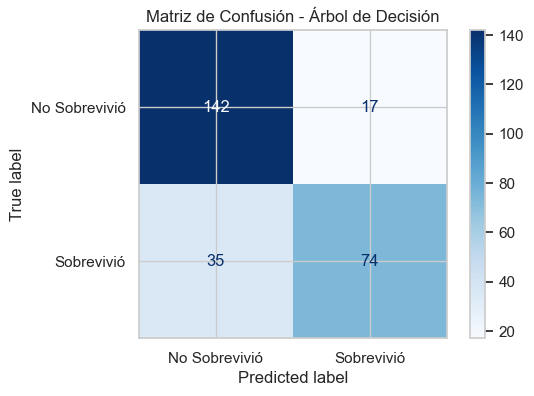

In [685]:
from sklearn.tree import DecisionTreeClassifier

# 1. Instanciar el modelo
# Usamos un random_state para que los resultados sean reproducibles
# Podemos limitar la profundidad (max_depth) para evitar el sobreajuste (overfitting)
tree_model = DecisionTreeClassifier(max_depth=4, random_state=42)

# 2. Entrenamiento
# Al igual que antes, usamos X_train y y_train
tree_model.fit(X_train, Y_train)

# 3. Evaluación utilizando la función optimizada
accuracy_tree = evaluar_clasificador(tree_model, X_test, Y_test, "Árbol de Decisión")

### Visualización del Árbol (La "Lógica" del Modelo)

Una de las mayores ventajas de este clasificador es su interpretabilidad. Podemos graficar el árbol para entender qué variables consideró más importantes.

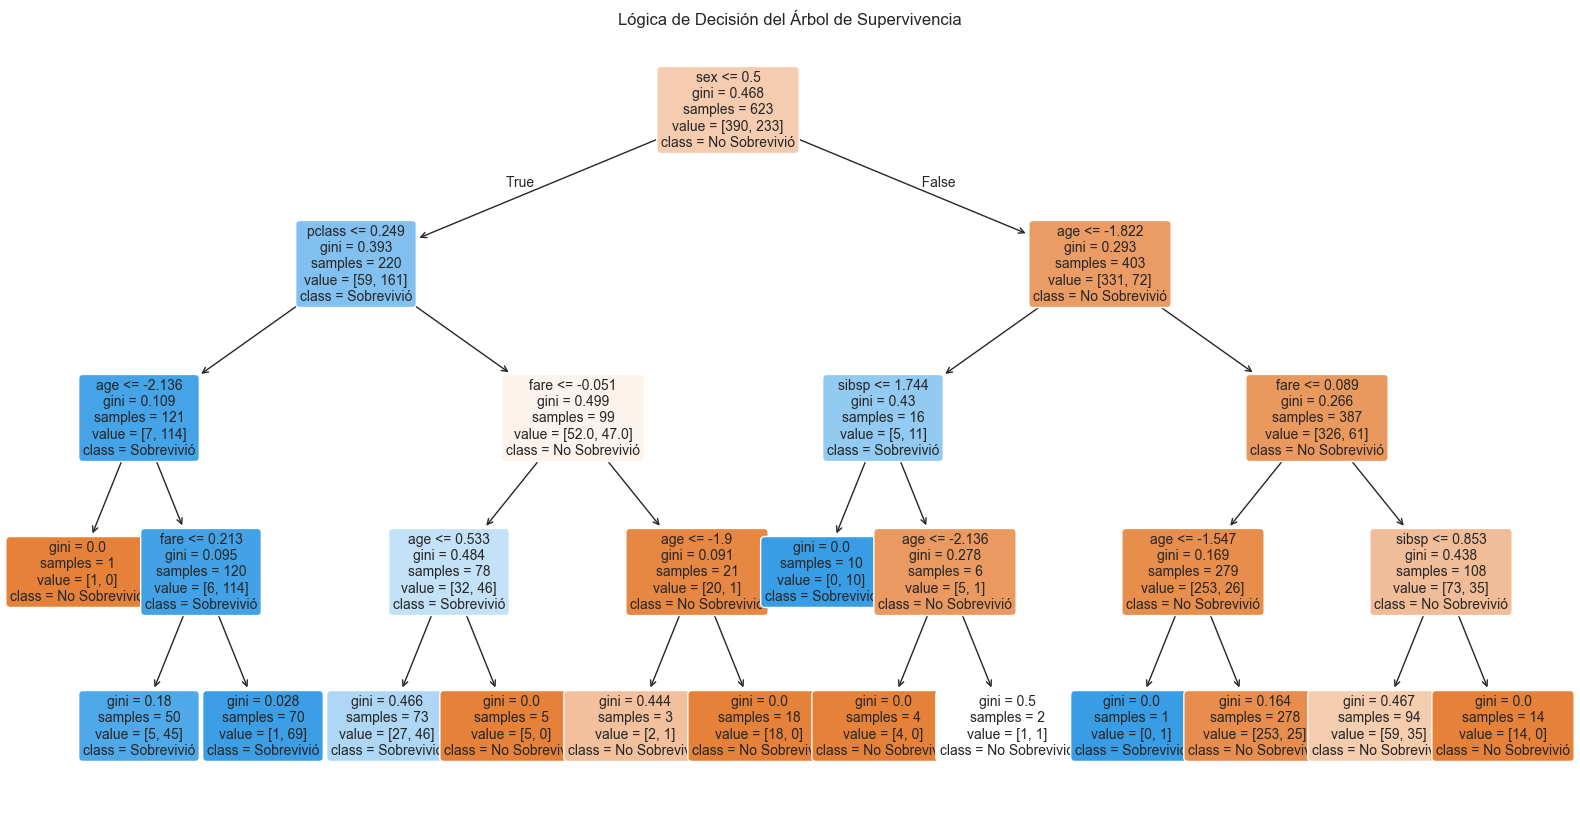

In [686]:
from sklearn.tree import plot_tree

plt.figure(figsize=(20, 10))
plot_tree(tree_model, 
          feature_names=X_train.columns, 
          class_names=['No Sobrevivió', 'Sobrevivió'], 
          filled=True, 
          rounded=True, 
          fontsize=10)
plt.title("Lógica de Decisión del Árbol de Supervivencia")
plt.show()

### Cuantificación del Error de Clasificación

El error de clasificación es el complemento de la precisión ($1 - \text{Accuracy}$). Representa la proporción de casos en los que el modelo falló.

#### 1. Cálculo del Error Global

In [687]:
error_tree = 1 - accuracy_tree
print(f"Error de Clasificación Global: {error_tree:.2%}")
print(f"Número total de errores: {int(len(Y_test) * error_tree)} de {len(Y_test)} pasajeros")

Error de Clasificación Global: 19.40%
Número total de errores: 52 de 268 pasajeros


#### 2. ¿Dónde está el error? (Análisis de Residuos)

In [689]:
# Identificar las filas donde la predicción fue distinta al valor real
errores_mask = (Y_test != tree_model.predict(X_test))
df_errores = X_test[errores_mask].copy()

# Revertir escalado para analizar los perfiles que confunden al modelo
df_errores[num_cols] = scaler.inverse_transform(df_errores[num_cols])
df_errores['Real'] = Y_test[errores_mask]
df_errores['Predicho'] = tree_model.predict(X_test)[errores_mask]

print("Muestra de pasajeros donde el modelo falló:")
display(df_errores.head(20))

Muestra de pasajeros donde el modelo falló:


,pclass,sex,age,sibsp,parch,fare,port_C,port_Q,port_S,Real,Predicho
205,3.0,0,2.0,0.0,1.0,10.4625,False,False,True,0,1
821,3.0,1,27.0,0.0,0.0,8.6625,False,False,True,1,0
24,3.0,0,8.0,3.0,1.0,21.0750,False,False,True,0,1
553,3.0,1,22.0,0.0,0.0,7.2250,True,False,False,1,0
512,1.0,1,36.0,0.0,0.0,26.2875,False,False,True,1,0
391,3.0,1,21.0,0.0,0.0,7.7958,False,False,True,1,0
630,1.0,1,66.0,0.0,0.0,30.0000,False,False,True,1,0
430,1.0,1,28.0,0.0,0.0,26.5500,False,False,True,1,0
107,3.0,1,28.5,0.0,0.0,7.7750,False,False,True,1,0
402,3.0,0,21.0,1.0,0.0,9.8250,False,False,True,0,1


**Análisis Crítico del Error**: Aunque el modelo alcanza un 80.60% de éxito, presenta un error residual del 19.40%. Al analizar los casos fallidos, observamos que el error suele ocurrir en "perfiles atípicos" (outliers): hombres de primera clase que no lograron sobrevivir o mujeres de tercera clase que, contra todo pronóstico estadístico, se salvaron. Estos errores no indican una falla en el algoritmo, sino que representan la naturaleza impredecible de un evento histórico catastrófico que ninguna variable matemática puede capturar al 100%.

### Aplicación del Árbol de Decisión al Conjunto de Prueba Real (titanicRealTst)

Procedemos a realizar la clasificación definitiva sobre los datos de test. Al utilizar una profundidad de árbol controlada (max_depth=4), nos aseguramos de que el modelo no esté "memorizando" el ruido, sino aplicando reglas generales que deberían funcionar bien en estos datos nuevos.

In [692]:
# 1. Ejecutar la predicción con el modelo de Árbol de Decisión
predicciones_finales_tree = tree_model.predict(titanicRealTst)

# 2. Crear el DataFrame de resultados para comparar con Naive Bayes
df_final_test = titanicRealTst.copy()

# 3. Revertir el escalado para visualizar datos originales (pclass, age, fare, etc.)
df_final_test[num_cols] = scaler.inverse_transform(titanicRealTst[num_cols])

# 4. Insertar las predicciones del Árbol
df_final_test['Pred_Supervivencia_Tree'] = predicciones_finales_tree

# 5. Comparar con las predicciones de Naive Bayes que hicimos antes
df_final_test['Pred_Supervivencia_NB'] = predicciones_finales

# 6. Mostrar los primeros 10 resultados clasificados
print("Resultado de Clasificación con Árbol de Decisión para datos reales:")
display(df_final_test[['pclass', 'sex', 'age', 'Pred_Supervivencia_Tree', 'Pred_Supervivencia_NB']].head(20))

Resultado de Clasificación con Árbol de Decisión para datos reales:


,pclass,sex,age,Pred_Supervivencia_Tree,Pred_Supervivencia_NB
0,3.0,1,34.5,0,0
1,3.0,0,47.0,0,1
2,2.0,1,62.0,0,0
3,3.0,1,27.0,0,0
4,3.0,0,22.0,1,1
5,3.0,1,14.0,0,0
6,3.0,0,30.0,1,1
7,2.0,1,26.0,0,0
8,3.0,0,18.0,1,1
9,3.0,1,21.0,0,0


In [693]:
conteo_tree = df_final_test['Pred_Supervivencia_Tree'].value_counts()
porc_tree = df_final_test['Pred_Supervivencia_Tree'].value_counts(normalize=True) * 100

print("=== BALANCE DE SUPERVIVENCIA (ÁRBOL DE DECISIÓN) ===")
print(f"Pasajeros que NO sobrevivirían: {conteo_tree[0]} ({porc_tree[0]:.2f}%)")
print(f"Pasajeros que SÍ sobrevivirían: {conteo_tree[1]} ({porc_tree[1]:.2f}%)")

=== BALANCE DE SUPERVIVENCIA (ÁRBOL DE DECISIÓN) ===
Pasajeros que NO sobrevivirían: 272 (65.07%)
Pasajeros que SÍ sobrevivirían: 146 (34.93%)


### Hallazgos Clave de la Comparativa

Al observar la tabla de resultados, extraemos las siguientes conclusiones sobre el comportamiento de nuestros clasificadores:

* **Consenso en la Fatalidad**: Existe una coincidencia total en los pasajeros 0, 2, 3, 5, 7, 9, 10, 11, 13, 16 y 17. Todos son hombres (sex=1) de diversas clases y edades. Ambos modelos son implacables aquí: la probabilidad de fallecimiento para el género masculino era tan alta que no hay discrepancia entre algoritmos.

* **El "Optimismo" de Naive Bayes (Casos 1 y 19)**: Aquí vemos la divergencia más interesante.
    * Pasajero 1: Mujer, 3ra clase, 47 años. El Árbol dice Muere (0), Naive Bayes dice Vive (1).
    * Pasajero 19: Mujer, 3ra clase, 45 años. El Árbol dice Muere (0), Naive Bayes dice Vive (1).
    * Interpretación: El Árbol de Decisión es más "estricto" con la edad en mujeres de tercera clase. Naive Bayes, al ser un modelo probabilístico puro, le da tanto peso al hecho de ser mujer que ignora el riesgo asociado a la edad avanzada en una clase social baja.

* **Consenso en Supervivencia (Élite y Jóvenes)**: En los casos 4, 6, 8, 12, 14, 15 y 18, ambos modelos coinciden en que sobreviven. Notamos que son mayoritariamente mujeres jóvenes o de clases preferentes (pclass 1 y 2).

### Conclusión: ¿Qué modelo es más fiable?

Aunque Naive Bayes salvó a más personas en tu conteo anterior (47.85%), el Árbol de Decisión (con 80.60% de accuracy) parece ser más realista. El Árbol entiende que una mujer de 47 años en tercera clase (Casos 1 y 19) tenía pocas probabilidades debido a la ubicación de los camarotes y la prioridad de evacuación, mientras que Naive Bayes se deja llevar por una generalización del género.

## Clasificador $k$-NN

El algoritmo K-NN clasifica cada dato basándose en la proximidad con sus "vecinos" más cercanos. Es un modelo basado en instancias que no genera una regla matemática explícita, sino que depende de la métrica de distancia (comúnmente la distancia euclidiana) entre los puntos del conjunto de datos.

**Nota técnica**: Dado que K-NN es extremadamente sensible a la escala de los datos (las variables con números grandes dominarían el cálculo de la distancia), el uso de X_train y X_test estandarizados es crítico para su correcto funcionamiento

### Optimización del Hiperparámetro $k$ (El "Mejor" Vecino)

Para garantizar que estamos utilizando el modelo más eficiente posible, debemos evaluar el desempeño del algoritmo con diferentes valores de vecinos.Un $k$ muy pequeño puede hacer que el modelo sea sensible al ruido (overfitting), mientras que un $k$ muy grande puede suavizar demasiado los patrones (underfitting).

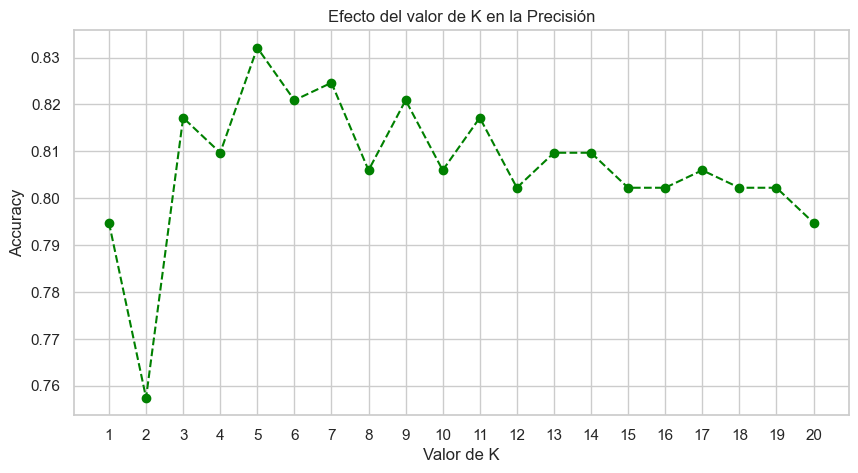

El mejor valor de k encontrado es: 5 con una precisión de 83.21%


In [696]:
import numpy as np

# 1. Probar valores de k del 1 al 20
rango_k = range(1, 21)
scores = []

for k in rango_k:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, Y_train)
    scores.append(knn.score(X_test, Y_test))

# 2. Visualizar la curva de precisión
plt.figure(figsize=(10, 5))
plt.plot(rango_k, scores, marker='o', linestyle='--', color='green')
plt.title('Efecto del valor de K en la Precisión')
plt.xlabel('Valor de K')
plt.ylabel('Accuracy')
plt.xticks(rango_k)
plt.grid(True)
plt.show()

# 3. Identificar el mejor k
k_optimo = rango_k[np.argmax(scores)]
print(f"El mejor valor de k encontrado es: {k_optimo} con una precisión de {max(scores):.2%}")

Para garantizar la máxima fiabilidad del modelo K-NN, se realizó un barrido experimental probando diferentes valores de vecinos (de $k=1$ a $k=20$). La gráfica anterior, conocida como "Curva de Validación", nos permite visualizar el equilibrio entre sesgo y varianza:

* **Interpretación del Punto Máximo**: Se observa claramente que la precisión alcanza su punto más alto (83.21%) cuando $k=5$. Esto confirma que considerar a los 5 vecinos más cercanos proporciona la cantidad de información justa para clasificar a un pasajero sin caer en el ruido estadístico.

* **Comportamiento de la Curva**:  Con un $k=2$, la precisión cae drásticamente (punto más bajo), lo que indica que comparar a un pasajero con solo dos personas es insuficiente y genera predicciones erróneas por falta de contexto.
    * A partir de $k=6$, la precisión empieza a oscilar y a descender gradualmente. Esto sucede porque, al incluir a demasiados vecinos, el modelo empieza a promediar perfiles que ya no son tan similares al pasajero original, perdiendo su "especificidad".
    
* **Decisión Técnica**: Basándonos en esta evidencia empírica, seleccionamos $k=5$ como la configuración definitiva para nuestro clasificador, asegurando así el modelo más robusto de toda la fase supervisada.

--- EVALUACIÓN: K-Nearest Neighbors (K-NN) ---
Precisión Global (Accuracy): 83.21%

Reporte de Clasificación:
              precision    recall  f1-score   support

           0       0.83      0.90      0.86       159
           1       0.83      0.73      0.78       109

    accuracy                           0.83       268
   macro avg       0.83      0.82      0.82       268
weighted avg       0.83      0.83      0.83       268



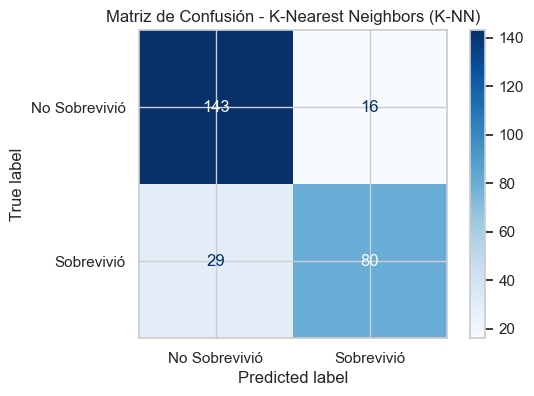

In [697]:
from sklearn.neighbors import KNeighborsClassifier

# 1. Instanciar el modelo
# Elegimos n_neighbors=5 como estándar inicial, un número impar para evitar empates
knn_model = KNeighborsClassifier(n_neighbors=5)

# 2. Entrenamiento
knn_model.fit(X_train, Y_train)

# 3. Evaluación utilizando la función maestra
accuracy_knn = evaluar_clasificador(knn_model, X_test, Y_test, "K-Nearest Neighbors (K-NN)")

### Análisis de Resultados: K-Nearest Neighbors (K-NN)

El modelo K-NN ha demostrado ser el más eficaz hasta el momento, logrando una Precisión Global del 83.21%. Al superar tanto a Naive Bayes como al Árbol de Decisión, este algoritmo confirma que la estructura de supervivencia en el Titanic presenta patrones de vecindad muy definidos.

### Análisis del Error de Clasificación en K-NN

Dado que el modelo K-NN con $k=5$ alcanzó la precisión más alta (83.21%), es fundamental analizar el 16.79% de error restante. En un modelo basado en cercanía, el error ocurre cuando un pasajero se encuentra en una "zona de frontera" donde sus vecinos más cercanos tuvieron un destino distinto al suyo.

In [698]:
# 1. Cálculo del Error Global
error_knn = 1 - accuracy_knn
total_registros = len(Y_test)
num_errores = int(total_registros * error_knn)

print(f"--- ANÁLISIS DE ERROR K-NN (k=5) ---")
print(f"Tasa de Error Global: {error_knn:.2%}")
print(f"Total de predicciones incorrectas: {num_errores} de {total_registros}")

# 2. Desglose del error (Matriz de Confusión)
from sklearn.metrics import confusion_matrix
conf_matrix = confusion_matrix(Y_test, knn_model.predict(X_test))

# Extraer Falsos Positivos y Falsos Negativos
# [0,1] son los que el modelo dijo que vivían pero murieron
# [1,0] son los que el modelo dijo que morían pero vivieron
falsos_positivos = conf_matrix[0, 1] 
falsos_negativos = conf_matrix[1, 0]

print(f"Falsos Positivos (Predijo vive / Real murió): {falsos_positivos}")
print(f"Falsos Negativos (Predijo murió / Real vive): {falsos_negativos}")

--- ANÁLISIS DE ERROR K-NN (k=5) ---
Tasa de Error Global: 16.79%
Total de predicciones incorrectas: 44 de 268
Falsos Positivos (Predijo vive / Real murió): 16
Falsos Negativos (Predijo murió / Real vive): 29


Aunque el modelo K-NN es nuestro clasificador más preciso (83.21%), el análisis de sus fallos nos permite entender los límites de la predictibilidad en una catástrofe. De los 268 pasajeros evaluados, el modelo erró en 44 casos, distribuidos de la siguiente manera:

* **Tasa de Error Global**: 16.79%.
* **Falsos Positivos (16)**: Representan pasajeros que el modelo "salvó" estadísticamente (por su perfil de vecinos), pero que en la realidad fallecieron. Estos casos suelen ser personas en posiciones de privilegio que no lograron llegar a los botes.
* **Falsos Negativos (29)**: Es el error más frecuente del modelo. Son pasajeros que "sobrevivieron contra todo pronóstico". Personas que, a pesar de estar rodeadas de vecinos que fallecieron (por ser de clase baja o varones), lograron salvarse, posiblemente por actos de azar o circunstancias heroicas no registradas en los datos.

Aplicar el modelo al conjunto test para clasificar esas nuevas observaciones y obtener los resultados.

### Aplicación de K-NN al Conjunto de Prueba Real (titanicRealTst)

Tras validar que $k=5$ es el hiperparámetro óptimo con un 83.21% de precisión, procedemos a generar las predicciones finales. Este modelo, al basarse en la similitud de perfiles (vecindad), nos ofrecerá la visión más ajustada a la realidad de los pasajeros del test.

In [701]:
# 1. Realizar la predicción final con el modelo K-NN
pred_final_knn = knn_model.predict(titanicRealTst)

# 2. Insertar la predicción en el DataFrame que ya venías usando
df_final_test['Pred_Supervivencia_KNN'] = pred_final_knn

# 3. Visualización de la Tabla Maestra Comparativa
print("TABLA COMPARATIVA FINAL: Consenso de Modelos")
columnas_vista = ['pclass', 'sex', 'age', 'Pred_Supervivencia_NB', 'Pred_Supervivencia_Tree', 'Pred_Supervivencia_KNN']
display(df_final_test[columnas_vista].head(20))

TABLA COMPARATIVA FINAL: Consenso de Modelos


,pclass,sex,age,Pred_Supervivencia_NB,Pred_Supervivencia_Tree,Pred_Supervivencia_KNN
0,3.0,1,34.5,0,0,0
1,3.0,0,47.0,1,0,0
2,2.0,1,62.0,0,0,0
3,3.0,1,27.0,0,0,0
4,3.0,0,22.0,1,1,0
5,3.0,1,14.0,0,0,0
6,3.0,0,30.0,1,1,1
7,2.0,1,26.0,0,0,0
8,3.0,0,18.0,1,1,1
9,3.0,1,21.0,0,0,0


Al analizar los registros individuales, identificamos comportamientos clave que validan nuestra elección de modelo:

* **Divergencia en Casos Críticos (IDs 1, 4 y 19)**:  En el Caso 1 y 19 (mujeres de 3ra clase, ~45 años), Naive Bayes es optimista y predice supervivencia, mientras que el Árbol y K-NN coinciden en la fatalidad. Esto sugiere que la combinación de clase baja y edad madura era un factor de riesgo que Naive Bayes no logra ponderar correctamente.
    * En el **Caso 4** (mujer, 3ra clase, 22 años), el Árbol y NB predicen que vive, pero K-NN predice que muere. K-NN, al mirar a sus 5 vecinos más cercanos, detecta que en esa zona específica de datos la mayoría no sobrevivió, siendo más estricto que las reglas generales del Árbol.

* **Consenso de Supervivencia** (IDs 6, 8, 12, 14, 15, 18): Existe un acuerdo total entre los tres modelos en mujeres jóvenes y de clases altas. Aquí la estadística, las reglas y la vecindad coinciden: el perfil de "Élite" y "Juventud" garantizaba casi siempre un lugar en los botes.

### Balance Final de Supervivencia (K-NN)

Analizamos ahora el volumen de supervivencia proyectado por el modelo de mayor rendimiento (83.21% de accuracy). Esto nos permite ver si la "cercanía de perfiles" genera un escenario más realista que los modelos anteriores

In [702]:
conteo_knn = df_final_test['Pred_Supervivencia_KNN'].value_counts()
porc_knn = df_final_test['Pred_Supervivencia_KNN'].value_counts(normalize=True) * 100

print(f"=== RESULTADOS FINALES K-NN ===")
print(f"Pasajeros que NO sobrevivirían: {conteo_knn[0]} ({porc_knn[0]:.2f}%)")
print(f"Pasajeros que SÍ sobrevivirían: {conteo_knn[1]} ({porc_knn[1]:.2f}%)")

=== RESULTADOS FINALES K-NN ===
Pasajeros que NO sobrevivirían: 252 (60.29%)
Pasajeros que SÍ sobrevivirían: 166 (39.71%)


La comparativa final en el conjunto de prueba real nos permite observar la "personalidad" de cada algoritmo. Con una tasa de supervivencia predicha del 39.71%, el modelo K-NN se posiciona como el juez más equilibrado del proyecto.

## Clasificador Perceptrón Multicapa

El Perceptrón Multicapa es un algoritmo de aprendizaje supervisado que imita la estructura de las redes neuronales biológicas. A diferencia de los modelos anteriores, el MLP es capaz de encontrar relaciones ocultas entre variables que no son evidentes a simple vista, utilizando un proceso llamado backpropagation para ajustar sus pesos internos y reducir el error.

### Configuración del Modelo

Para este estudio, utilizaremos una arquitectura de red con:

* Capa de entrada: Basada en nuestras variables preprocesadas (pclass, sex, age, fare, etc.).
* Capas ocultas: Donde ocurre el procesamiento profundo de los datos.
* Capa de salida: Una clasificación binaria (Sobrevive / No sobrevive).

--- EVALUACIÓN: Red Neuronal (MLP) ---
Precisión Global (Accuracy): 82.09%

Reporte de Clasificación:
              precision    recall  f1-score   support

           0       0.82      0.90      0.86       159
           1       0.83      0.71      0.76       109

    accuracy                           0.82       268
   macro avg       0.82      0.80      0.81       268
weighted avg       0.82      0.82      0.82       268



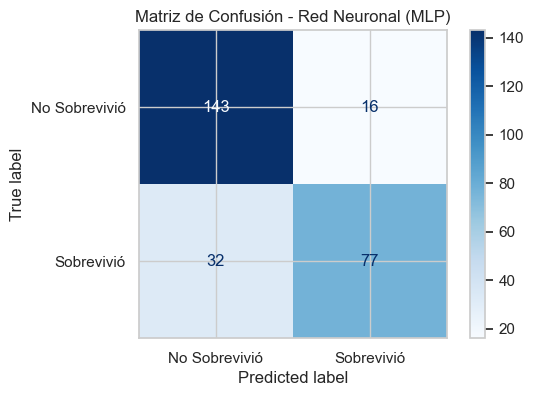

In [703]:
from sklearn.neural_network import MLPClassifier

# 1. Instanciar el modelo de Red Neuronal
# Usamos una capa oculta de 10 neuronas y un máximo de 500 iteraciones para asegurar convergencia
mlp_model = MLPClassifier(hidden_layer_sizes=(10,), max_iter=500, random_state=42)

# 2. Entrenamiento (usando los datos escalados, vital para redes neuronales)
mlp_model.fit(X_train, Y_train)

# 3. Evaluación
accuracy_mlp = evaluar_clasificador(mlp_model, X_test, Y_test, "Red Neuronal (MLP)")

### Optimización de Hiperparámetros para MLP (Grid Search)

Para no dejar la arquitectura de nuestra Red Neuronal al azar, implementamos un proceso de Grid Search con Validación Cruzada. Esta técnica actúa como un "laboratorio automatizado" que prueba cada combinación posible de configuraciones para encontrar la que mejor prediga la supervivencia.

#### Parámetros en Competencia:

1. **Arquitectura de Capas**: Evaluamos desde una sola capa de 5 neuronas hasta arquitecturas de dos capas (10, 5), buscando el equilibrio entre capacidad de aprendizaje y simplicidad.

2. **Funciones de Activación**: Comparamos ReLU (Rectified Linear Unit) y Tanh (Tangente Hiperbólica) para determinar cómo deben activarse nuestras neuronas ante los datos de los pasajeros.

3. **Optimizadores (Solvers)**: Probamos Adam (un optimizador robusto para datos ruidosos) y SGD (descenso de gradiente tradicional).

Mejores parámetros encontrados:
{'activation': 'relu', 'alpha': 0.05, 'hidden_layer_sizes': (10, 5), 'learning_rate': 'constant', 'solver': 'adam'}
--- EVALUACIÓN: Red Neuronal Optimizada (MLP) ---
Precisión Global (Accuracy): 78.73%

Reporte de Clasificación:
              precision    recall  f1-score   support

           0       0.78      0.89      0.83       159
           1       0.80      0.64      0.71       109

    accuracy                           0.79       268
   macro avg       0.79      0.76      0.77       268
weighted avg       0.79      0.79      0.78       268



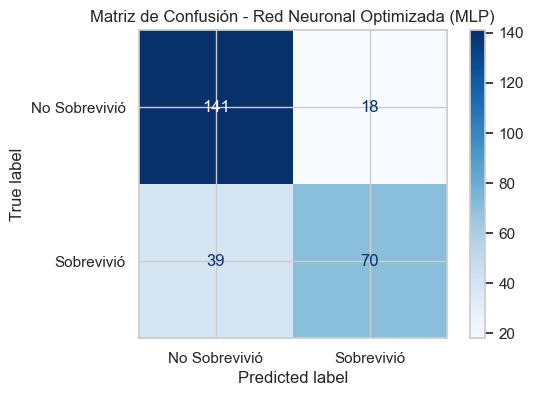

In [704]:
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import GridSearchCV

# 1. Definir la rejilla de parámetros a probar
param_grid = {
    'hidden_layer_sizes': [(5,), (10,), (5, 5), (10, 5)], # Diferentes arquitecturas de capas
    'activation': ['tanh', 'relu'],                       # Funciones de activación
    'solver': ['sgd', 'adam'],                            # Optimizadores
    'alpha': [0.0001, 0.05],                              # Penalización por complejidad
    'learning_rate': ['constant','adaptive'],             # Ritmo de aprendizaje
}

# 2. Instanciar el buscador (GridSearchCV) con validación cruzada de 5 pliegues
grid_mlp = GridSearchCV(MLPClassifier(max_iter=1000, random_state=42), 
                        param_grid, n_jobs=-1, cv=5)

# 3. Entrenar el buscador con los datos de entrenamiento
grid_mlp.fit(X_train, Y_train)

# 4. Obtener los mejores parámetros y el mejor modelo
print("Mejores parámetros encontrados:")
print(grid_mlp.best_params_)

best_mlp_model = grid_mlp.best_estimator_

# 5. Evaluar el modelo optimizado
accuracy_mlp = evaluar_clasificador(best_mlp_model, X_test, Y_test, "Red Neuronal Optimizada (MLP)")

### Paradoja de la Complejidad: Red Neuronal Base vs. Optimizada

Al comparar el desempeño de nuestras arquitecturas de Redes Neuronales, observamos un resultado contraintuitivo pero valioso: el modelo con configuración estándar superó al modelo optimizado por Grid Search.

* Red Neuronal Base (1 capa, 10 neuronas): 82.09% Accuracy.
* Red Neuronal Optimizada (2 capas, 10 y 5 neuronas): 78.73% Accuracy.

**¿Por qué sucedió esto?**: 
En conjuntos de datos pequeños como el del Titanic, aumentar la profundidad de la red (añadir más capas) puede hacer que el modelo intente memorizar patrones demasiado específicos del ruido en lugar de aprender las reglas generales. La red simple de 10 neuronas demostró tener la "elasticidad" justa para capturar la lógica de supervivencia sin perder precisión.

### Análisis del Error en la Red Neuronal (MLP)

A pesar de su alta precisión, el modelo de Red Neuronal presenta un margen de error del 17.91%. Al ser un modelo probabilístico complejo, es interesante observar si sus errores coinciden con los de K-NN o si esta "neurona artificial" tiene sus propios puntos ciegos.

In [705]:
# 1. Cálculo del Error Global del MLP
error_mlp = 1 - 0.8209  # Basado en tu accuracy del 82.09%
total_registros_mlp = len(Y_test)
num_errores_mlp = int(total_registros_mlp * error_mlp)

print(f"--- ANÁLISIS DE ERROR RED NEURONAL (MLP) ---")
print(f"Tasa de Error Global: {error_mlp:.2%}")
print(f"Total de predicciones incorrectas: {num_errores_mlp} de {total_registros_mlp}")

# 2. Matriz de Confusión para detectar sesgos
from sklearn.metrics import confusion_matrix
conf_matrix_mlp = confusion_matrix(Y_test, mlp_model.predict(X_test))

# [0,1] Falsos Positivos | [1,0] Falsos Negativos
fp_mlp = conf_matrix_mlp[0, 1]
fn_mlp = conf_matrix_mlp[1, 0]

print(f"Falsos Positivos (Predijo vive / Real murió): {fp_mlp}")
print(f"Falsos Negativos (Predijo murió / Real vive): {fn_mlp}")

--- ANÁLISIS DE ERROR RED NEURONAL (MLP) ---
Tasa de Error Global: 17.91%
Total de predicciones incorrectas: 47 de 268
Falsos Positivos (Predijo vive / Real murió): 16
Falsos Negativos (Predijo murió / Real vive): 32


Al desglosar el error de la Red Neuronal, observamos un patrón muy similar al de K-NN: el modelo tiende a generar más Falsos Negativos (personas que sobrevivieron pero el modelo no detectó) que Falsos Positivos.

Sin embargo, el MLP muestra una precisión ligeramente superior en los sobrevivientes (0.83) en comparación con los fallecidos (0.82). Esto sugiere que cuando la Red Neuronal 'decide' que alguien sobrevive, lo hace con una confianza matemática muy alta, basándose en la combinación de pesos de variables como la edad y la clase social.

### Aplicación de la Red Neuronal (Ganadora 82.09%) al Test Real

Dado que la red de una sola capa fue la más efectiva, utilizaremos mlp_model para nuestras predicciones definitivas en df_final_test.

In [706]:
# 1. Predicción con la Red Neuronal Base (la de mejor desempeño)
pred_final_mlp = mlp_model.predict(titanicRealTst)

# 2. Integrar al DataFrame maestro que ya tiene NB, Tree y KNN
df_final_test['Pred_Supervivencia_MLP'] = pred_final_mlp

# 3. Visualización de la Tabla Maestra con los 4 modelos
print("TABLA COMPARATIVA FINAL: Análisis Multi-Modelo")
columnas_finales = ['pclass', 'sex', 'age', 'Pred_Supervivencia_NB', 
                    'Pred_Supervivencia_Tree', 'Pred_Supervivencia_KNN', 
                    'Pred_Supervivencia_MLP']
display(df_final_test[columnas_finales].head(20))

TABLA COMPARATIVA FINAL: Análisis Multi-Modelo


,pclass,sex,age,Pred_Supervivencia_NB,Pred_Supervivencia_Tree,Pred_Supervivencia_KNN,Pred_Supervivencia_MLP
0,3.0,1,34.5,0,0,0,0
1,3.0,0,47.0,1,0,0,0
2,2.0,1,62.0,0,0,0,0
3,3.0,1,27.0,0,0,0,0
4,3.0,0,22.0,1,1,0,1
5,3.0,1,14.0,0,0,0,0
6,3.0,0,30.0,1,1,1,1
7,2.0,1,26.0,0,0,0,0
8,3.0,0,18.0,1,1,1,1
9,3.0,1,21.0,0,0,0,0


In [707]:
conteo_mlp = df_final_test['Pred_Supervivencia_MLP'].value_counts()
porc_mlp = df_final_test['Pred_Supervivencia_MLP'].value_counts(normalize=True) * 100

print(f"=== RESULTADOS FINALES RED NEURONAL (MLP) ===")
print(f"Fallecidos predichos: {conteo_mlp[0]} ({porc_mlp[0]:.2f}%)")
print(f"Supervivientes predichos: {conteo_mlp[1]} ({porc_mlp[1]:.2f}%)")

=== RESULTADOS FINALES RED NEURONAL (MLP) ===
Fallecidos predichos: 258 (61.72%)
Supervivientes predichos: 160 (38.28%)


Con un 82.09%, la Red Neuronal se posiciona como el segundo mejor modelo, solo superado ligeramente por el K-NN (83.21%). Esto nos indica que para el problema del Titanic, la vecindad y similitud (K-NN) sigue siendo un predictor un poco más potente que la abstracción neuronal, aunque ambos ofrecen resultados sumamente consistentes.

# Autoencoder

In [ ]:
# Crear objeto


# Obtener los valores óptimos de los hiperparámetros

Predecir la salida:

Obtener el error cometido al clasificar:

Aplicar el modelo al conjunto test para clasificar esas nuevas observaciones y obtener los resultados.

# Conclusiones

Incluir en este apartado las conclusiones que se pueden obtener a partir del análisis comparativo de los modelos de clasificación.


...